# Energy-Efficient and Dynamics-Robust 7-DOF Arm Control
### A reproducible MuJoCo · Gymnasium · PyTorch experiment

**Research question:** Can deep RL learn accurate, smooth, low-effort joint control while tolerating rigid-body dynamics shifts?

Upload this single notebook to **Google Colab**, select a Python runtime, and **Run all**. `STANDARD` runs PD, PPO, SAC, TD3, validation-only selection, equal-budget reward ablations, then one held-out nominal/robustness test campaign. No private keys or local assets are needed. The standard budget targets roughly 60–90 minutes but is **not a measured runtime guarantee**; Colab CPUs vary substantially. Runtime estimates are printed after pilots. Do not interpret an undertrained policy as evidence that its algorithm cannot solve the task.

`QUICK` verifies the entire pipeline with tiny budgets; its outputs are explicitly debugging results. This delivered notebook has no fabricated training outputs. Running it generates all tables, plots, models, CSVs and videos. The optional cache directory may point to an **already mounted** Drive directory; `/content` is lost when Colab deletes the runtime.

**Protocol:** specify all decisions → train/tune on training and validation only → freeze every policy, including ablations → unlock test targets once → report failures and uncertainty.


**Colab startup compatibility (v3):** Preserve the installed scientific stack and use CSV logging. The setup cell disables PyTorch's optional TensorBoard import so SB3 does not load TensorFlow/XLA alongside the OSMesa renderer. No TensorFlow packages are removed. Run this notebook in a restarted session before importing TensorFlow or JAX. A subprocess checks scientific imports, SB3's non-TensorBoard path, MuJoCo stepping and actual headless rendering before the notebook imports the simulation libraries. The missing-CUDA message is not itself an error; this experiment runs on CPU.

Import-path references: [SB3's optional logger import](https://github.com/DLR-RM/stable-baselines3/blob/v2.7.1/stable_baselines3/common/logger.py), [TensorBoard's TensorFlow compatibility loader](https://github.com/tensorflow/tensorboard/blob/master/tensorboard/compat/__init__.py).


## 1 · What the robot and learner do

A **degree of freedom (DOF)** is an independent motion coordinate. Here seven hinge joints have angles $q_i$ (rad), angular velocities $\dot q_i$ (rad/s), and applied **torques** $\tau_i$ (N·m). The links form a serial chain from the fixed base to the **end effector**, a site on the hand. **Forward kinematics** maps joint angles to that site's 3D position. Seven angles determine only three position coordinates, so many configurations can reach the same point; orientation is intentionally unconstrained.

**Mass** measures translational resistance; **inertia** also depends on where that mass lies relative to a rotation axis. **Damping** resists velocity; joint **friction loss** resists sliding motion. **Actuator strength** sets how much torque a command produces. A **payload** is additional mass carried near the end effector, with its own inertia.

$$\text{observation}\rightarrow\text{policy}\rightarrow\text{7 motor commands}\rightarrow
\text{MuJoCo physics}\rightarrow\text{new state}\rightarrow\text{reward}.$$

MuJoCo integrates dynamics conceptually described by
$$M(q)\ddot q+C(q,\dot q)\dot q+g(q)+f(q,\dot q)=\tau,$$
with joint constraints and contacts. The policy learns useful actions, **not the laws of physics**. No IK, gravity compensation, or Cartesian controller transforms RL actions.


In [1]:
# Preserve Colab's compatible scientific stack; never downgrade a loaded NumPy.
import os, sys, subprocess, platform
import importlib.metadata as setup_metadata
from pathlib import Path as SetupPath

SCIENTIFIC_PACKAGES = ("numpy", "pandas", "scipy", "matplotlib", "torch")
TASK_PACKAGES = ["mujoco==3.3.7", "gymnasium==1.2.2", "stable-baselines3==2.7.1",
                 "imageio==2.37.0", "imageio-ffmpeg==0.6.0"]
MODULE_PACKAGES = {name:name for name in SCIENTIFIC_PACKAGES}
MODULE_PACKAGES.update({"mujoco":"mujoco", "gymnasium":"gymnasium",
                       "stable_baselines3":"stable-baselines3", "imageio":"imageio"})

def installed_version(package):
    try: return setup_metadata.version(package)
    except setup_metadata.PackageNotFoundError: return None

def stale_modules():
    stale=[]
    for module,package in MODULE_PACKAGES.items():
        loaded=sys.modules.get(module)
        memory_version=getattr(loaded,"__version__",None)
        disk_version=installed_version(package)
        if memory_version is not None and disk_version is not None and str(memory_version)!=disk_version:
            stale.append(f"{module}: memory={memory_version}, installed={disk_version}")
    return stale

def require_clean_kernel():
    stale=stale_modules()
    if stale:
        raise RuntimeError("Packages in this session are stale: " + "; ".join(stale) +
            ". In Colab select Runtime > Restart session, then Run all again. "
            "Do not try to reload NumPy or remove it from sys.modules.")

# SB3's optional TensorBoard import can load TensorFlow/XLA into the process.
# This experiment logs to CSV and does not use TensorBoard. Python's negative
# import-cache entry makes SB3 use its supported ImportError fallback instead.
# Do not uninstall TensorFlow or change Colab's system packages to achieve this.
for native_module in ("tensorflow", "jaxlib"):
    if native_module in sys.modules:
        raise RuntimeError(f"{native_module} is already loaded in this kernel. "
            "Restart the session and run this notebook first, before importing TensorFlow or JAX.")
sys.modules["torch.utils.tensorboard"] = None

# Catch an already mixed session before changing anything else.
require_clean_kernel()
if platform.system()=="Linux":
    if "mujoco" in sys.modules and os.environ.get("MUJOCO_GL")!="osmesa":
        raise RuntimeError("MuJoCo is already imported with a different renderer. "
                           "Restart the session and Run all so headless rendering is set before import.")
    os.environ["MUJOCO_GL"]="osmesa"
    subprocess.run(["apt-get","-qq","update"],check=True)
    subprocess.run(["apt-get","-qq","install","-y","libosmesa6","libgl1","libegl1"],check=True)

setup_dir=SetupPath("/content/panda_rl_setup" if SetupPath("/content").exists() else "work/panda_rl_setup")
setup_dir.mkdir(parents=True,exist_ok=True)
retained={p:installed_version(p) for p in SCIENTIFIC_PACKAGES}
constraints=setup_dir/"constraints.txt"
constraints.write_text("\n".join(f"{p}=={v}" for p,v in retained.items() if v)+"\n")
# Constraints prevent indirect NumPy/SciPy/Torch changes by dependency resolution too.
missing=[p for p,v in retained.items() if v is None]
subprocess.check_call([sys.executable,"-m","pip","install","-q","--upgrade-strategy","only-if-needed",
                       "--constraint",str(constraints),*TASK_PACKAGES,*missing])
require_clean_kernel()

# Check both a fresh interpreter and this kernel, including NumPy's lazy string module.
IMPORT_PROBE = """
import sys
# The child interpreter does not inherit the parent's sys.modules guard.
sys.modules["torch.utils.tensorboard"] = None
print("[startup] Scientific imports", flush=True)
import numpy as np
from numpy import *
if int(np.__version__.split('.')[0]) >= 2:
    import numpy.strings
import pandas, matplotlib.pyplot, scipy
from scipy.optimize import least_squares
print("[startup] PyTorch, MuJoCo and Gymnasium", flush=True)
import torch, mujoco, gymnasium
print("[startup] Stable-Baselines3 with CSV logging", flush=True)
from stable_baselines3 import PPO, SAC, TD3
from stable_baselines3.common import logger as sb3_logger
assert sb3_logger.SummaryWriter is None, "Optional TensorBoard path was not disabled"
assert "tensorflow" not in sys.modules, "Unexpected TensorFlow import"
import imageio.v2
assert np.allclose(least_squares(lambda x: x-1., [0.]).x, [1.])
"""
# Exercise native stepping and rendering in the child first: a native library
# abort cannot be caught with try/except in the notebook kernel.
RENDER_PROBE = """
print("[startup] MuJoCo stepping and headless rendering", flush=True)
model = mujoco.MjModel.from_xml_string('<mujoco><worldbody><body pos="0 0 0.3"><joint type="hinge"/><geom type="capsule" size="0.04 0.15"/></body></worldbody></mujoco>')
data = mujoco.MjData(model)
for _ in range(5): mujoco.mj_step(model, data)
renderer = mujoco.Renderer(model, height=32, width=32)
try:
    renderer.update_scene(data)
    pixels = renderer.render()
    assert pixels.shape == (32, 32, 3)
finally:
    renderer.close()
print("[startup] Native rendering passed", flush=True)
"""
probe=subprocess.run([sys.executable,"-u","-c",IMPORT_PROBE+RENDER_PROBE],capture_output=True,text=True)
print(probe.stdout)
if probe.returncode:
    print(probe.stderr)
    raise RuntimeError(f"Startup subprocess exited with code {probe.returncode}. "
        "The last [startup] stage above identifies whether imports or rendering failed; "
        "no training has started. Save this notebook with its output if you need to report the diagnostic.")
try:
    exec(IMPORT_PROBE,{})
except Exception as exc:
    raise RuntimeError("The installed packages work in a fresh process, but this kernel has stale imports. "
                       "Select Runtime > Restart session, then Run all again.") from exc
print("Startup imports, SciPy optimization, MuJoCo stepping and headless rendering passed.")
print("Preserved scientific stack:",{p:installed_version(p) for p in SCIENTIFIC_PACKAGES})


[startup] Scientific imports
[startup] PyTorch, MuJoCo and Gymnasium
[startup] Stable-Baselines3 with CSV logging
[startup] MuJoCo stepping and headless rendering
[startup] Native rendering passed

[startup] Scientific imports
[startup] PyTorch, MuJoCo and Gymnasium
[startup] Stable-Baselines3 with CSV logging
Startup imports, SciPy optimization, MuJoCo stepping and headless rendering passed.
Preserved scientific stack: {'numpy': '2.1.3', 'pandas': '2.2.3', 'scipy': '1.16.3', 'matplotlib': '3.10.0', 'torch': '2.11.0+cpu'}


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [2]:
import copy, hashlib, importlib.metadata as im, json, random, time, traceback
import urllib.request, xml.etree.ElementTree as ET
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
from scipy.optimize import least_squares
import torch, mujoco, gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO, SAC, TD3
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.noise import NormalActionNoise
from IPython.display import display, Video, Markdown
import imageio.v2 as imageio

plt.rcParams.update({"figure.dpi": 125, "savefig.dpi": 180, "axes.spines.top": False,
                     "axes.spines.right": False, "axes.grid": True, "grid.alpha": .2})
VERSIONS = {p: im.version(p) for p in ["mujoco", "gymnasium", "stable-baselines3",
            "torch", "numpy", "pandas", "matplotlib", "scipy", "imageio", "imageio-ffmpeg"]}
print(json.dumps({"packages": VERSIONS, "python": sys.version, "platform": platform.platform(),
      "cpu_count": os.cpu_count(), "cuda": torch.cuda.is_available()}, indent=2))


{
  "packages": {
    "mujoco": "3.3.7",
    "gymnasium": "1.2.2",
    "stable-baselines3": "2.7.1",
    "torch": "2.11.0+cpu",
    "numpy": "2.1.3",
    "pandas": "2.2.3",
    "matplotlib": "3.10.0",
    "scipy": "1.16.3",
    "imageio": "2.37.0",
    "imageio-ffmpeg": "0.6.0"
  },
  "python": "3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "cpu_count": 2,
  "cuda": false
}


## 2 · Configuration and predeclared decisions

Training uses nominal physics. Two learning rates receive equal pilot budgets for each algorithm. The best validation setting starts a **fresh**, equally budgeted final run. Three fresh ablations of the validation-winning RL algorithm receive that same final budget and seed; its full-reward run supplies condition D. A second training seed is configurable but increases time substantially.

Checkpoint selection is lexicographic: higher validation success, lower mean final error (rounded to 1 mm), lower average squared torque, then lower mean action variation. This is a declared preference, not a claim that effort matters only after accuracy. Test outcomes never select a controller, checkpoint, video target, or reward. Validation selection introduces optimism on validation; only test uncertainty is reported as held-out evidence.


In [3]:
MODE = "STANDARD"  # QUICK is ONLY a pipeline debug run
CACHE_DIR = None   # e.g. "/content/drive/MyDrive/panda_rl_cache" AFTER mounting Drive
RUN_OBSERVATION_ABLATION = False
CFG = {
    "schema": "panda-torque-v1.0", "mode": MODE, "seed": 20260922,
    "model_commit": "822c2d8f877dd166c5b7d3c9f7e3c3b6589473b7",
    "sim_dt": .002, "frame_skip": 10, "horizon": 200, "tolerance": .03, "hold": 10,
    "q_home": [0., -.45, 0., -1.9, 0., 1.5, .75],
    "target_q_halfwidth": [.50,.40,.50,.40,.50,.40,.50], "joint_margin": .15,
    "workspace_low": [.15,-.45,.12], "workspace_high": [.80,.45,.85],
    "target_min_distance": .06, "joint_soft_margin": .12, "limit_slack": .08,
    "frictionloss": .10, "velocity_scale": 5.,
    "limit_solref": [.004,1.], "limit_solimp": [.95,.99,.001],
    "reward": {"reach": 2., "success": 2., "effort": .04, "smooth": .08,
               "limits": .20, "collision": .50},
    "split_seeds": {"train": 101, "validation": 202, "test": 303},
    "training_seeds": [11],  # use [11, 29] for independent training replications
    "pilot_steps": 32768 if MODE == "STANDARD" else 512,
    "final_steps": 196608 if MODE == "STANDARD" else 1024,
    "eval_every": 32768 if MODE == "STANDARD" else 512,
    "validation_n": 12 if MODE == "STANDARD" else 3,
    "test_n": 48 if MODE == "STANDARD" else 4,
    "robust_n": 16 if MODE == "STANDARD" else 2,
    "train_target_n": 4096 if MODE == "STANDARD" else 128,
    "learning_rates": [3e-4, 1e-4], "network": [128,128], "gamma": .98,
    "ppo": {"n_steps": 1024 if MODE == "STANDARD" else 256, "batch_size": 256,
            "n_epochs": 5, "gae_lambda": .95, "clip_range": .2, "ent_coef": .0},
    "off_policy": {"buffer_size": 200000 if MODE == "STANDARD" else 4096, "batch_size": 256,
                   "learning_starts": 3000 if MODE == "STANDARD" else 128,
                   "train_freq": 4, "gradient_steps": 1, "tau": .005},
    "perturbations": {"mass": [.8,.9,1.1,1.2], "payload": [.25,.5,1.0],
                      "damping": [.5,1.5,2.], "friction": [.5,1.5,2.],
                      "strength": [.8,.9,1.1,1.2]},
    "mass_links": ["link4","link5","link6","link7"],
    "observation_ablation": RUN_OBSERVATION_ABLATION,
    "device": "cpu", "torch_threads": 1,
}
assert MODE in ("QUICK", "STANDARD")
if MODE == "QUICK":
    # Debugging never opens STANDARD's validation/test banks.
    CFG["split_seeds"] = {k:v+100000 for k,v in CFG["split_seeds"].items()}
    CFG["perturbations"] = {k:[v[0]] for k,v in CFG["perturbations"].items()}
random.seed(CFG["seed"]); np.random.seed(CFG["seed"]); torch.manual_seed(CFG["seed"])
if torch.cuda.is_available(): torch.cuda.manual_seed_all(CFG["seed"])
torch.set_num_threads(CFG["torch_threads"])
torch.use_deterministic_algorithms(True, warn_only=True)
torch.backends.cudnn.benchmark = False
def digest(obj): return hashlib.sha256(json.dumps(obj, sort_keys=True).encode()).hexdigest()[:16]
ROOT = Path(CACHE_DIR or ("/content/panda_rl" if Path("/content").exists() else "work/panda_rl"))
ROOT.mkdir(parents=True, exist_ok=True)
RUN = ROOT / digest({"cfg": CFG, "versions": VERSIONS})
RUN.mkdir(exist_ok=True)
def save_json(path, obj):
    path = Path(path); tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(json.dumps(obj, indent=2, default=lambda x: x.tolist() if isinstance(x,np.ndarray) else str(x)))
    tmp.replace(path)
save_json(RUN/"configuration.json", CFG); save_json(RUN/"versions.json", VERSIONS)
print("Run directory:", RUN, "\nMode:", MODE)


Run directory: /content/panda_rl/22d17b54f98f1a8d 
Mode: STANDARD


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Seeds control Python, NumPy, PyTorch, target banks, environment resets and SB3. CPU is intentional: small MLP updates often do not benefit from GPU transfer overhead, and MuJoCo stepping is CPU work. Library/CPU differences, floating-point arithmetic, GPU kernels if enabled, and resumed runs can still differ. Checkpoints resume weights, optimizer and replay buffer; they **do not recreate the exact interrupted trajectory or RNG stream**. Archive `versions.json` for repeatability.

## 3 · Public Panda model → seven torque motors

We pin a Menagerie commit and download its MJCF plus referenced meshes and license. The original position servos are replaced with unit-gear motors, with limits ±87 N·m for joints 1–4 and ±12 N·m for 5–7. The two finger bodies are removed: this is an arm with its rigid hand, no finger DOFs. An inertial payload attachment at the end-effector site starts at a negligible 1 g; tests add specified kg. Nominal joint friction loss is explicitly set to 0.1 N·m so multiplier tests are meaningful. Original link masses, inertias, damping and contact meshes are retained. These modifications define a **Panda-style simulation**, not a certified hardware model.

The exact nominal mapping is $u_i=L_i\,\mathrm{clip}(a_i,-1,1)$ and $\tau_i=u_i$. In strength tests fixed command limits are retained and motor gain becomes $s$, with force limits $\pm sL_i$, so $\tau_i=s u_i$. A stronger motor genuinely produces more torque. No position-servo bias remains.

Joint-stop solver settings are tightened to a 4 ms reference time constant (`solreflimit=[0.004,1]`, `solimplimit=[0.95,0.99,0.001]`): the source model's softer stops allowed excessive penetration under direct full-range torque. This changes constraint compliance, not joint positions or the RL commands. The random-torque check below still measures remaining penetration.


In [4]:
ASSETS = ROOT / ("menagerie_" + CFG["model_commit"][:12])
ASSETS.mkdir(exist_ok=True); (ASSETS/"assets").mkdir(exist_ok=True)
BASE = f"https://raw.githubusercontent.com/google-deepmind/mujoco_menagerie/{CFG['model_commit']}/franka_emika_panda/"
def fetch(relative):
    dest = ASSETS/relative
    if not dest.exists():
        for attempt in range(3):
            try:
                with urllib.request.urlopen(BASE+relative, timeout=60) as r: blob = r.read()
                tmp = dest.with_suffix(dest.suffix+".download"); tmp.write_bytes(blob); tmp.replace(dest)
                break
            except Exception:
                if attempt == 2: raise
                time.sleep(1+attempt)
    return dest
fetch("panda.xml"); fetch("LICENSE")
tree = ET.parse(ASSETS/"panda.xml"); root = tree.getroot()
mesh_files = sorted({"assets/"+x.attrib["file"] for x in root.findall("asset/mesh")})
with ThreadPoolExecutor(max_workers=8) as pool: list(pool.map(fetch, mesh_files))
asset_hashes = {str(p.relative_to(ASSETS)): hashlib.sha256(p.read_bytes()).hexdigest()
                for p in [ASSETS/"panda.xml", ASSETS/"LICENSE"] + [ASSETS/x for x in mesh_files]}
save_json(RUN/"asset_hashes.json", asset_hashes)
for tag in ["actuator", "tendon", "equality", "keyframe"]:
    for node in root.findall(tag): root.remove(node)
hand = root.find(".//body[@name='hand']")
for node in list(hand.findall("body")): hand.remove(node)
ET.SubElement(hand,"site",name="ee",pos="0 0 .10",size=".012",rgba="0.1 0.8 1 1")
payload = ET.SubElement(hand,"body",name="payload",pos="0 0 .10")
ET.SubElement(payload,"inertial",pos="0 0 0",mass=".001",diaginertia="0.00000036 0.00000036 0.00000036")
world = root.find("worldbody")
ET.SubElement(world,"geom",name="floor",type="plane",size="2 2 .1",pos="0 0 -.01",rgba=".18 .21 .26 1")
marker = ET.SubElement(world,"body",name="target",mocap="true",pos=".5 0 .5")
ET.SubElement(marker,"geom",type="sphere",size=str(CFG["tolerance"]),contype="0",conaffinity="0",rgba="1 .2 .1 .45")
act = ET.SubElement(root,"actuator")
LIMITS = np.array([87.]*4 + [12.]*3)
for i, lim in enumerate(LIMITS,1):
    ET.SubElement(act,"motor",name=f"torque{i}",joint=f"joint{i}",gear="1",
                  ctrllimited="true",ctrlrange=f"{-lim} {lim}",forcelimited="true",forcerange=f"{-lim} {lim}")
root.find("compiler").set("meshdir", str((ASSETS/"assets").resolve()))
root.find("option").set("timestep",str(CFG["sim_dt"]))
for j in root.findall(".//body/joint"):
    j.set("frictionloss",str(CFG["frictionloss"]))
    # The source's soft position-servo stops allow excessive penetration under full torque.
    j.set("solreflimit"," ".join(map(str,CFG["limit_solref"])))
    j.set("solimplimit"," ".join(map(str,CFG["limit_solimp"])))
MODEL_XML = ET.tostring(root, encoding="unicode")
(RUN/"panda_torque.xml").write_text(MODEL_XML)
def make_model(): return mujoco.MjModel.from_xml_string(MODEL_XML)
M0 = make_model()
assert M0.nq == M0.nv == M0.nu == 7, "Model must contain exactly seven arm DOFs and motors"
assert np.all(M0.actuator_biastype == mujoco.mjtBias.mjBIAS_NONE)
assert np.allclose(M0.actuator_gainprm[:,0],1) and np.allclose(M0.actuator_gear[:,0],1)
JOINT_IDS = np.array([M0.joint(f"joint{i}").id for i in range(1,8)])
assert np.array_equal(M0.actuator_trnid[:,0], JOINT_IDS)
LOW, HIGH = M0.jnt_range[JOINT_IDS].T.copy()
HOME = np.array(CFG["q_home"])
DT = CFG["sim_dt"]*CFG["frame_skip"]
robot_table = pd.DataFrame({"joint": [f"joint{i}" for i in range(1,8)],
    "lower_rad": LOW, "upper_rad": HIGH, "torque_limit_Nm": LIMITS,
    "damping_Nms_rad": M0.dof_damping, "frictionloss_Nm": M0.dof_frictionloss,
    "armature_kgm2": M0.dof_armature})
link_table = pd.DataFrame([{"body": M0.body(i).name,
    "parent": M0.body(int(M0.body_parentid[i])).name, "mass_kg": M0.body_mass[i],
    "principal_inertia_kgm2": M0.body_inertia[i].tolist()} for i in range(1,M0.nbody)])
display(robot_table, link_table)
print(f"Simulation {CFG['sim_dt']} s; control {DT} s ({1/DT:g} Hz)")
robot_table.to_csv(RUN/"joints.csv", index=False); link_table.to_csv(RUN/"links.csv", index=False)
print("Contact friction [sliding, torsional, rolling], unique rows:",np.unique(M0.geom_friction,axis=0))
print("Actuator dynamics types:",M0.actuator_dyntype,"; unit gear; no activation state or position bias")


,joint,lower_rad,upper_rad,torque_limit_Nm,damping_Nms_rad,frictionloss_Nm,armature_kgm2
0,joint1,-2.8973,2.8973,87.0,1.0,0.1,0.1
1,joint2,-1.7628,1.7628,87.0,1.0,0.1,0.1
2,joint3,-2.8973,2.8973,87.0,1.0,0.1,0.1
3,joint4,-3.0718,-0.0698,87.0,1.0,0.1,0.1
4,joint5,-2.8973,2.8973,12.0,1.0,0.1,0.1
5,joint6,-0.0175,3.7525,12.0,1.0,0.1,0.1
6,joint7,-2.8973,2.8973,12.0,1.0,0.1,0.1


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,body,parent,mass_kg,principal_inertia_kgm2
0,link0,world,0.629769,"[0.004304650123430994, 0.0038798390919025367, ..."
1,link1,link0,4.970684,"[0.7071370144883009, 0.7034354292338564, 0.008..."
2,link2,link1,0.646926,"[0.03103264256517663, 0.02830010693683385, 0.0..."
3,link3,link2,3.228604,"[0.04150138828861061, 0.041479257270665607, 0...."
4,link4,link3,3.587895,"[0.03495964042412706, 0.028148276242039156, 0...."
5,link5,link4,1.225946,"[0.036762538266730406, 0.028853091260661545, 0..."
6,link6,link5,1.666555,"[0.005842761226567758, 0.004310373704197247, 0..."
7,link7,link6,0.735522,"[0.012734492874724473, 0.01010547714435622, 0...."
8,hand,link7,0.730000,"[0.001, 0.0025, 0.0017]"
9,payload,hand,0.001000,"[3.6e-07, 3.6e-07, 3.6e-07]"


Simulation 0.002 s; control 0.02 s (50 Hz)
Contact friction [sliding, torsional, rolling], unique rows: [[1.e+00 5.e-03 1.e-04]]
Actuator dynamics types: [0 0 0 0 0 0 0] ; unit gear; no activation state or position bias


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 4 · Reachable target banks and leakage controls

Sample angles in a bounded neighborhood of home, strictly inside joint limits; forward kinematics supplies the XYZ target. Reject out-of-workspace targets, initially trivial targets and configurations with penetrating contacts. A 16-point interpolated joint path from home is also collision-checked. This proves a sampled collision-free kinematic path (at finite resolution), **not** guaranteed dynamic feasibility or a globally collision-free workspace. The controller sees only the target position, never the generating angles or sampled path.

Training samples with replacement from a reproducible 4,096-configuration bank. Validation uses its own fixed seed. Test generation is deferred until the freeze cell; split hashes and configurations are saved. The same target and reset seeds are reused across controllers and physical conditions, enabling paired comparisons. The bank distribution is deliberately local to make direct torque learning practical; conclusions do not cover the entire Panda workspace.


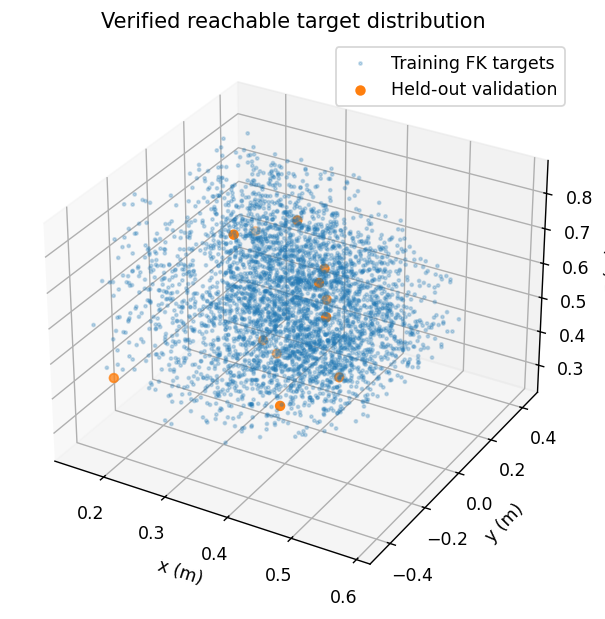

In [5]:
def contact_count(model, data):
    # Count penetrating collision pairs; visual geoms / target are disabled for contact.
    return sum(data.contact[i].dist < -1e-5 for i in range(data.ncon))

def target_bank(n, seed):
    rng = np.random.default_rng(seed); model = make_model(); data = mujoco.MjData(model)
    site = model.site("ee").id
    def fk(q):
        data.qpos[:] = q; data.qvel[:] = 0; mujoco.mj_forward(model,data)
        return data.site_xpos[site].copy()
    home_p = fk(HOME)
    assert contact_count(model,data) == 0, "Home configuration is in collision"
    qs, ps = [], []
    half = np.array(CFG["target_q_halfwidth"])
    lo = np.maximum(LOW+CFG["joint_margin"], HOME-half)
    hi = np.minimum(HIGH-CFG["joint_margin"], HOME+half)
    for _ in range(n*300):
        q = rng.uniform(lo,hi); p = fk(q)
        if np.any(p < CFG["workspace_low"]) or np.any(p > CFG["workspace_high"]): continue
        if np.linalg.norm(p-home_p) < CFG["target_min_distance"]: continue
        valid = True
        for t in np.linspace(0,1,16):
            fk(HOME+t*(q-HOME))
            if contact_count(model,data): valid=False; break
        if not valid: continue
        qs.append(q); ps.append(p)
        if len(qs)==n: break
    if len(qs)!=n: raise RuntimeError(f"Only {len(qs)}/{n} reachable targets; inspect workspace settings")
    bank = {"q":np.array(qs),"p":np.array(ps),"seed":seed}
    # Independent roundtrip check: every target has a joint-configuration witness.
    assert max(np.linalg.norm(fk(q)-p) for q,p in zip(bank["q"],bank["p"])) < 1e-10
    return bank

TRAIN = target_bank(CFG["train_target_n"],CFG["split_seeds"]["train"])
VAL = target_bank(CFG["validation_n"],CFG["split_seeds"]["validation"])
for name, bank in [("train",TRAIN),("validation",VAL)]:
    np.savez_compressed(RUN/f"targets_{name}.npz",**bank)
assert not set(map(tuple,TRAIN["q"])) & set(map(tuple,VAL["q"]))
fig = plt.figure(figsize=(7,5)); ax=fig.add_subplot(projection="3d")
ax.scatter(*TRAIN["p"].T,s=3,alpha=.25,label="Training FK targets")
ax.scatter(*VAL["p"].T,s=25,label="Held-out validation")
ax.set(xlabel="x (m)",ylabel="y (m)",zlabel="z (m)",title="Verified reachable target distribution")
ax.legend(); fig.tight_layout(); fig.savefig(RUN/"workspace.png"); plt.show()


## 5 · Observations, rewards and the environment

The requested core has **23 values**: seven angles, seven velocities, EE position, target position and target error. Angles are centered/scaled by limits; velocity is divided by 5 rad/s; Cartesian values use a 1 m scale. We append seven previous normalized commands, the hold fraction and remaining-time fraction: **32 values total**. These nine measured/history variables make the action-change cost and finite-horizon hold task observable; no dynamics parameters or IK solution are exposed. The optional no-error variant has 29 values. Fixed normalization prevents validation/test-statistic leakage.

The dense term is $2[\exp(-d/0.10)-1-d/0.50]\leq0$. The subtraction of 1 prevents positive living reward from making prolonged hovering preferable to successful termination. The one-time success bonus is 2. Effort cost is mean $(\tau_i/L_i)^2$; smoothness cost is mean $(a_i-a_{i,t-1})^2$. Small weights keep both below typical distance effects. Joint-limit cost grows quadratically within 0.12 rad of a limit; any penetrating collision adds a per-step penalty. Every weighted component is logged separately.

**Squared torque is not physical energy.** We report $\int\sum_i\tau_i^2dt$ in (N·m)²·s and absolute actuator mechanical work $\int\sum_i|\tau_i\dot q_i|dt$ in J. The latter excludes motor losses, regeneration accounting and electronics. Substep integration measures applied torque, including strength changes, rather than assuming command equals torque.

Success requires distance <3 cm for 10 consecutive control steps (0.2 s). Success terminates; the time limit truncates. Other termination is reserved for numerical failure, recorded as failure. MuJoCo joint limits are compliant constraints, so small penetration is possible: violations are measured, never removed by teleporting the joint state.


In [6]:
class Dynamics:
    """Each instance owns a model; all changes start from its saved nominal parameters."""
    fields = ("body_mass","body_inertia","dof_damping","dof_frictionloss",
              "actuator_gainprm","actuator_forcerange")
    def __init__(self, model):
        self.m = model; self.nominal = {k:getattr(model,k).copy() for k in self.fields}
    def apply(self, factor="nominal", value=1.):
        for k,v in self.nominal.items(): getattr(self.m,k)[:] = v
        if factor=="mass":
            ids=[self.m.body(x).id for x in CFG["mass_links"]]
            self.m.body_mass[ids] *= value; self.m.body_inertia[ids] *= value
        elif factor=="payload":
            i=self.m.body("payload").id
            self.m.body_mass[i] += value
            self.m.body_inertia[i] += .4*value*.03**2 # 3 cm solid sphere at its COM
        elif factor=="damping": self.m.dof_damping[:] *= value
        elif factor=="friction": self.m.dof_frictionloss[:] *= value
        elif factor=="strength":
            self.m.actuator_gainprm[:,0] *= value
            self.m.actuator_forcerange[:] *= value
        elif factor!="nominal": raise ValueError(factor)
        changed={k for k in self.fields if not np.array_equal(getattr(self.m,k),self.nominal[k])}
        expected={"nominal":set(),"mass":{"body_mass","body_inertia"},
                  "payload":{"body_mass","body_inertia"},"damping":{"dof_damping"},
                  "friction":{"dof_frictionloss"},"strength":{"actuator_gainprm","actuator_forcerange"}}[factor]
        if value==1 and factor!="payload": expected=set()
        assert changed==expected, f"Unexpected physical mutation: {changed} != {expected}"
        scratch=mujoco.MjData(self.m); mujoco.mj_setConst(self.m,scratch)
        return {k:getattr(self.m,k).tolist() for k in self.fields}

def reward_terms(distance, success, effort_rate, smooth_rate, q, collisions, weights):
    margin=np.minimum(q-LOW,HIGH-q)
    raw={"reach":float(np.exp(-distance/.10)-1-distance/.50),"success":float(success),
         "effort":-effort_rate,"smooth":-smooth_rate,
         "limits":-float(np.mean(np.maximum(0,1-margin/CFG["joint_soft_margin"])**2)),
         "collision":-float(collisions>0)}
    return {k:weights[k]*v for k,v in raw.items()}

class PandaReach(gym.Env):
    metadata={"render_modes":["rgb_array"],"render_fps":50}
    def __init__(self, bank=TRAIN, weights=None, factor="nominal", value=1., include_error=True):
        super().__init__()
        self.model=make_model(); self.data=mujoco.MjData(self.model)
        self.physics=Dynamics(self.model); self.physics.apply(factor,value)
        self.site=self.model.site("ee").id; self.bank=bank
        self.weights=copy.deepcopy(weights or CFG["reward"]); self.include_error=include_error
        self.action_space=spaces.Box(-1.,1.,shape=(7,),dtype=np.float32)
        self.observation_space=spaces.Box(-np.inf,np.inf,shape=(32 if include_error else 29,),dtype=np.float32)
        self.renderer=None
    def ee(self): return self.data.site_xpos[self.site].copy()
    def obs(self):
        p=self.ee(); core=[2*(self.data.qpos-LOW)/(HIGH-LOW)-1,
            self.data.qvel/CFG["velocity_scale"],p,self.target]
        if self.include_error: core.append(self.target-p)
        return np.concatenate(core+[self.prev_action,[self.hold/CFG["hold"],1-self.steps/CFG["horizon"]]]).astype(np.float32)
    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        idx=(options or {}).get("target_index")
        if idx is None: idx=int(self.np_random.integers(len(self.bank["p"])))
        mujoco.mj_resetData(self.model,self.data)
        self.data.qpos[:]=HOME  # fixed common start isolates reaching / physics effects
        self.target=self.bank["p"][idx].copy(); self.target_index=idx
        self.data.mocap_pos[0]=self.target
        self.prev_action=np.zeros(7); self.hold=0; self.steps=0
        mujoco.mj_forward(self.model,self.data)
        return self.obs(), {"target":self.target.copy(),"target_index":idx}
    def step(self, action):
        action=np.asarray(action,dtype=float)
        if action.shape!=(7,) or not np.all(np.isfinite(action)): raise ValueError("Expected seven finite motor commands")
        a=np.clip(action,-1,1); self.data.ctrl[:]=LIMITS*a
        p0=self.ee(); effort=work=normalized_effort=0.; contacts=violations=0; numerical_failure=False
        tau_sum=np.zeros(7)
        old_time=self.data.time
        for _ in range(CFG["frame_skip"]):
            mujoco.mj_step(self.model,self.data)
            tau=self.data.qfrc_actuator.copy()
            effort+=float(tau@tau)*CFG["sim_dt"]
            normalized_effort+=float(np.mean((tau/LIMITS)**2))/CFG["frame_skip"]
            work+=float(np.sum(np.abs(tau*self.data.qvel)))*CFG["sim_dt"]
            tau_sum+=tau
            contacts+=contact_count(self.model,self.data)
            violations+=int(np.any((self.data.qpos<LOW-.005)|(self.data.qpos>HIGH+.005)))
            if not np.all(np.isfinite(self.data.qpos)) or not np.all(np.isfinite(self.data.qvel)):
                numerical_failure=True; break
        # mj_step may internally forward before integration: refresh derived site positions.
        mujoco.mj_forward(self.model,self.data)
        numerical_failure |= self.data.time < old_time + DT*.9
        if not np.all(np.isfinite(self.data.qpos)): raise FloatingPointError("Nonfinite MuJoCo qpos")
        distance=float(np.linalg.norm(self.ee()-self.target)); self.steps+=1
        self.hold=self.hold+1 if distance<CFG["tolerance"] else 0
        success=self.hold>=CFG["hold"] and not numerical_failure
        delta=a-self.prev_action; smooth=float(np.mean(delta**2))
        terms=reward_terms(distance,success,normalized_effort,smooth,self.data.qpos,contacts,self.weights)
        reward=float(sum(terms.values())); self.prev_action=a.copy()
        info={"is_success":bool(success),"distance":distance,"effort":effort,"work":work,
              "smoothness":float(delta@delta),"trajectory_length":float(np.linalg.norm(self.ee()-p0)),
              "violations":violations,"collisions":contacts,"numerical_failure":bool(numerical_failure),
              "tau":tau_sum/CFG["frame_skip"],"reward_terms":terms}
        assert np.isfinite(reward) and np.all(np.isfinite(self.obs())), "Nonfinite environment output"
        return self.obs(),reward,bool(success or numerical_failure),bool(self.steps>=CFG["horizon"] and not success),info
    def render(self):
        if self.renderer is None: self.renderer=mujoco.Renderer(self.model,height=480,width=640)
        camera=mujoco.MjvCamera(); camera.lookat[:]=[.35,0,.4]
        camera.distance=1.65; camera.azimuth=135; camera.elevation=-25
        self.renderer.update_scene(self.data,camera=camera)
        return self.renderer.render()
    def close(self):
        if self.renderer is not None: self.renderer.close(); self.renderer=None


## 6 · Fail-fast checks before learning

Checks cover API shapes, deterministic transitions, FK witnesses, all seven motor transmissions, changing EE position, finite random rollouts, bounded commands and physically small limit penetration. Random full-range torques are intentionally a harsher test than useful control; a limit failure must be investigated, not clipped out of observations. Each perturbation is restored and checked. Numerical failures in later evaluations remain in the dataset as failures.


In [7]:
def sanity_checks():
    e=PandaReach(); check_env(e,warn=True)
    o,_=e.reset(seed=42); assert o.shape==(32,) and e.action_space.shape==(7,)
    assert e.observation_space.contains(o)
    p=e.ee(); e.step(np.ones(7,dtype=np.float32)*.15)
    assert np.linalg.norm(e.ee()-p)>1e-7, "Actions did not move EE"
    e.reset(seed=42); _,_,_,_,info=e.step(np.full(7,2.))
    assert np.all(np.abs(e.data.ctrl)<=LIMITS+1e-9)
    assert np.all(np.abs(e.data.qfrc_actuator)<=LIMITS+1e-8)
    a=PandaReach(); b=PandaReach(); oa,_=a.reset(seed=123); ob,_=b.reset(seed=123)
    assert np.array_equal(oa,ob)
    rng=np.random.default_rng(8)
    for _ in range(30):
        u=rng.uniform(-.2,.2,7); xa=a.step(u); xb=b.step(u)
        assert np.allclose(xa[0],xb[0],atol=1e-10) and xa[1]==xb[1]
    max_penetration=0.
    e.reset(seed=7)
    for k in range(1000):
        o,r,term,trunc,info=e.step(rng.uniform(-1,1,7))
        assert all(np.isfinite(v) for v in info["reward_terms"].values())
        penetration=max(0.,float(np.max(LOW-e.data.qpos)),float(np.max(e.data.qpos-HIGH)))
        max_penetration=max(max_penetration,penetration)
        assert penetration<CFG["limit_slack"], f"Joint limit penetration {penetration:.3f} rad"
        assert not info["numerical_failure"], "Random rollout numerical failure"
        if term or trunc: e.reset(seed=k)
    for factor,values in CFG["perturbations"].items():
        for value in values:
            e.physics.apply(factor,value); e.physics.apply()
            for field, nominal in e.physics.nominal.items():
                assert np.array_equal(getattr(e.model,field),nominal), field
    for env in (e,a,b): env.close()
    print(f"Sanity checks passed; max random-rollout limit penetration {max_penetration:.4f} rad")
    save_json(RUN/"sanity.json",{"passed":True,"max_penetration_rad":max_penetration})
sanity_checks()


Sanity checks passed; max random-rollout limit penetration 0.0199 rad


## 7 · Conventional control and common evaluation

**Inverse kinematics** numerically searches angles whose FK position matches the target. **PD control** converts angle error and measured velocity into torque, $\tau=K_p(q_{target}-q)-K_d\dot q$. The baseline below adds **nominal** gravity compensation; its internal model stays nominal during every physics test, so it does not receive true perturbed dynamics. IK uses only the target, fixed deterministic restarts and nominal kinematics, never the generating configuration. IK failure is logged and the best residual candidate is still evaluated.

We tune three PD gain settings on validation only. All controllers use the same torque clipping, start state, targets, horizon and hold criterion. PD has analytical structure and computational IK unavailable to RL; this is a conventional reference, not equal information or equal computation. IK residual and setup time are reported. Time-to-target includes the hold duration and is **NaN on failure**; report success-conditioned time with success rate, plus capped time where failures receive the horizon.

Early successful termination shortens cumulative effort. Report both cumulative effort and duration-normalized effort, and avoid claiming efficiency gains from failure or shorter observation time alone. Collision count means penetrating **contact-pair substeps**, not unique impacts; violations count simulation substeps with >0.005 rad limit penetration.


In [8]:
class PDController:
    def __init__(self, gain=1.):
        self.m=make_model(); self.d=mujoco.MjData(self.m); self.site=self.m.site("ee").id
        self.kp=gain*np.array([80,80,70,70,30,25,20.])
        self.kd=np.sqrt(gain)*np.array([18,18,15,15,6,5,4.]); self.cache={}
    def reset(self,target):
        key=tuple(target); start=time.perf_counter()
        if key not in self.cache:
            def residual(q):
                self.d.qpos[:]=q; self.d.qvel[:]=0; mujoco.mj_forward(self.m,self.d)
                return self.d.site_xpos[self.site]-target
            rng=np.random.default_rng(909); candidates=[]
            for x0 in [HOME]+[np.clip(HOME+rng.normal(0,.35,7),LOW+.02,HIGH-.02) for _ in range(3)]:
                result=least_squares(residual,x0,bounds=(LOW+.01,HIGH-.01),max_nfev=160,
                                     ftol=1e-8,xtol=1e-8,gtol=1e-8)
                self.d.qpos[:]=result.x; mujoco.mj_forward(self.m,self.d)
                score=np.linalg.norm(residual(result.x)) + (1. if contact_count(self.m,self.d) else 0.)
                candidates.append((score,result.x.copy()))
            _,q=min(candidates,key=lambda z:z[0]); self.cache[key]=(q,float(np.linalg.norm(residual(q))))
        self.qtarget,self.ik_residual=self.cache[key]; self.ik_seconds=time.perf_counter()-start
    def predict(self, obs, deterministic=True):
        q=LOW+(obs[:7]+1)*.5*(HIGH-LOW); qv=obs[7:14]*CFG["velocity_scale"]
        self.d.qpos[:]=q; self.d.qvel[:]=0.; mujoco.mj_forward(self.m,self.d)
        gravity=self.d.qfrc_bias.copy()
        return np.clip((self.kp*(self.qtarget-q)-self.kd*qv+gravity)/LIMITS,-1,1).astype(np.float32),None

def evaluate(controller, bank, label, factor="nominal", value=1., n=None, weights=None,
             include_error=True, trace=False, video_path=None):
    env=PandaReach(bank,weights,factor,value,include_error); rows=[]; traces=[]
    n=min(n or len(bank["p"]),len(bank["p"]))
    writer=None
    try:
        if video_path: writer=imageio.get_writer(str(video_path),fps=round(1/DT),codec="libx264")
        for idx in range(n):
            seed=int(bank["seed"]*100000+idx)
            obs,_=env.reset(seed=seed,options={"target_index":idx})
            if isinstance(controller,PDController): controller.reset(env.target)
            totals={k:0. for k in ["effort","work","smoothness","trajectory_length","violations","collisions"]}
            components={k:0. for k in CFG["reward"]}; ret=0.; traj=[]
            for step in range(CFG["horizon"]):
                action,_=controller.predict(obs,deterministic=True)
                obs,r,terminated,truncated,info=env.step(action); ret+=r
                for k in totals: totals[k]+=info[k]
                for k in components: components[k]+=info["reward_terms"][k]
                if trace: traj.append({"t":(step+1)*DT,"q":env.data.qpos.copy(),
                                        "tau":info["tau"].copy(),"error":info["distance"]})
                if writer and idx==0: writer.append_data(env.render())
                if terminated or truncated: break
            duration=(step+1)*DT
            rows.append({"controller":label,"seed":seed,"target_index":idx,
                **dict(zip(["target_x","target_y","target_z"],env.target)),
                "success":int(info["is_success"]),"final_error":info["distance"],
                "time_to_target":duration if info["is_success"] else np.nan,
                "capped_time":duration if info["is_success"] else CFG["horizon"]*DT,
                "duration":duration,"effort_rate":totals["effort"]/duration,
                "smoothness_rate":totals["smoothness"]/(step+1),
                "episode_return":ret,"factor":factor,"value":value,
                "condition":factor if factor=="nominal" else f"{factor}:{value:g}",
                "numerical_failure":int(info["numerical_failure"]),
                "ik_residual":getattr(controller,"ik_residual",np.nan),
                "ik_seconds":getattr(controller,"ik_seconds",np.nan),
                **totals,**{"reward_"+k:v for k,v in components.items()}})
            if trace: traces.append(traj)
    finally:
        if writer: writer.close()
        env.close()
    return pd.DataFrame(rows),traces

def selection_key(df):
    return (-float(df.success.mean()),round(float(df.final_error.mean()),3),
            float(df.effort_rate.mean()),float(df.smoothness_rate.mean()))
PD_CANDIDATES=[]
for gain in [.6,1.,1.5]:
    c=PDController(gain); frame,_=evaluate(c,VAL,"PD")
    PD_CANDIDATES.append((selection_key(frame),gain,frame))
_,PD_GAIN,pd_validation=min(PD_CANDIDATES,key=lambda x:x[0])
pd_validation.to_csv(RUN/"pd_validation.csv",index=False)
save_json(RUN/"pd_selection.json",{"gain":PD_GAIN,"candidates":[{"gain":g,"key":k} for k,g,_ in PD_CANDIDATES]})
print("Validation-selected PD gain:",PD_GAIN); display(pd_validation[["success","final_error","ik_residual"]].describe())


Validation-selected PD gain: 0.6


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,success,final_error,ik_residual
count,12.0,12.000000,1.200000e+01
mean,1.0,0.009513,7.813057e-10
std,0.0,0.003576,1.323145e-09
min,1.0,0.004297,2.941396e-12
25%,1.0,0.007674,8.516583e-12
50%,1.0,0.009027,2.412192e-11
75%,1.0,0.011121,1.084648e-09
max,1.0,0.016598,3.965695e-09


## 8 · PPO, SAC and TD3

| Method | Data and exploration | Practical distinction |
|---|---|---|
| **PPO** (principal RL reference) | On-policy stochastic policy; recent rollouts only | Clipped policy updates; old data is not reused indefinitely |
| **SAC** | Off-policy stochastic actor; replay buffer; learned entropy temperature | Encourages exploratory action distributions while learning value estimates |
| **TD3** | Off-policy deterministic actor; replay buffer; added Gaussian training noise | Twin critics, delayed actor updates and target-policy smoothing |

Off-policy methods can reuse transitions and be more sample-efficient, but performance depends on updates per collected step. Here SAC and TD3 use one gradient update per four steps to keep CPU runtime practical; PPO uses five epochs per rollout. All methods get equal interaction budgets, **not** equal update counts or compute. Their exact timing is logged. “Baseline” means a credible reference, not an expected loser. Evaluation uses deterministic predictions for all three.

Training logs raw per-episode returns and each reward term. Checkpoints include the optimizer, and SAC/TD3 replay state. Each compatible run has a hash of task, reward, hyperparameters, seed, dependency versions and model content. Completed runs load without retraining; partial runs resume from the most recent complete checkpoint directory. A small completion file is written only after all checkpoint files exist.


In [9]:
ALGOS={"PPO":PPO,"SAC":SAC,"TD3":TD3}
def code_signature(fn):
    # Bytecode plus recursively serialized constants: independent of notebook cell number/path.
    import types
    def signature(c):
        return {"bytecode":c.co_code.hex(),"names":c.co_names,
                "constants":[signature(v) if isinstance(v,types.CodeType) else repr(v) for v in c.co_consts]}
    return signature(fn.__code__)
IMPLEMENTATION_HASH=digest([code_signature(fn) for fn in [PandaReach.__init__,PandaReach.reset,
    PandaReach.step,PandaReach.obs,reward_terms,Dynamics.apply,target_bank,selection_key]])
def algorithm_kwargs(name,lr,seed):
    kw=dict(learning_rate=lr,gamma=CFG["gamma"],seed=seed,device=CFG["device"],
            policy_kwargs={"net_arch":CFG["network"]},verbose=0)
    if name=="PPO": kw.update(CFG["ppo"])
    else:
        kw.update(CFG["off_policy"])
        if name=="SAC": kw["ent_coef"]="auto"
        else: kw["action_noise"]=NormalActionNoise(np.zeros(7),.15*np.ones(7))
    return kw

class ValidationCheckpoint(BaseCallback):
    def __init__(self, directory, weights, include_error):
        super().__init__(); self.directory=directory; self.weights=weights; self.include_error=include_error
        self.next_eval=0; self.episode={}; self.episode_steps=0
        self.best_key=None; self.history=[]; self.episodes=[]
        if (directory/"selection.json").exists():
            self.best_key=tuple(json.loads((directory/"selection.json").read_text())["key"])
        if (directory/"validation.csv").exists(): self.history=pd.read_csv(directory/"validation.csv").to_dict("records")
        if (directory/"episodes.csv").exists(): self.episodes=pd.read_csv(directory/"episodes.csv").to_dict("records")
    def _on_training_start(self):
        self.next_eval=(self.num_timesteps//CFG["eval_every"]+1)*CFG["eval_every"]
    def validate(self):
        df,_=evaluate(self.model,VAL,"validation",weights=self.weights,include_error=self.include_error)
        key=selection_key(df)
        self.history.append({"timesteps":self.num_timesteps,"success":df.success.mean(),
            "final_error":df.final_error.mean(),"effort_rate":df.effort_rate.mean(),
            "smoothness_rate":df.smoothness_rate.mean()})
        pd.DataFrame(self.history).to_csv(self.directory/"validation.csv",index=False)
        if self.best_key is None or key<self.best_key:
            self.best_key=key
            self.model.save(self.directory/"best_pending")
            (self.directory/"best_pending.zip").replace(self.directory/"best.zip")
            df.to_csv(self.directory/"best_validation_episodes.csv",index=False)
            save_json(self.directory/"selection.json",{"key":key,"timesteps":self.num_timesteps})
        checkpoint=self.directory/f"checkpoint_{self.num_timesteps}_{time.time_ns()}"
        checkpoint.mkdir(exist_ok=True)
        self.model.save(checkpoint/"model")
        if hasattr(self.model,"save_replay_buffer"): self.model.save_replay_buffer(checkpoint/"replay.pkl")
        save_json(checkpoint/"ready.json",{"timesteps":self.num_timesteps})
        save_json(self.directory/"latest.json",{"checkpoint":checkpoint.name})
        # Keep two complete resume states to bound disk usage; preserve best.zip separately.
        checkpoints=sorted((p for p in self.directory.glob("checkpoint_*") if (p/"ready.json").exists()),
                           key=lambda p:int(p.name.split("_")[-1]))
        for old in checkpoints[:-2]:
            import shutil
            assert old.resolve().is_relative_to(self.directory.resolve()), "Unsafe checkpoint cleanup path"
            shutil.rmtree(old)
        print(f"{self.directory.name}: {self.num_timesteps:,} steps; val success {df.success.mean():.0%}, error {df.final_error.mean():.3f} m")
    def _on_step(self):
        self.episode_steps+=1
        info=self.locals["infos"][0]
        self.episode["episode_return"]=self.episode.get("episode_return",0)+float(self.locals["rewards"][0])
        for k,v in info["reward_terms"].items(): self.episode[k]=self.episode.get(k,0)+v
        if self.locals["dones"][0]:
            self.episodes.append({"timesteps":self.num_timesteps,"length":self.episode_steps,
                                  **self.episode,"success":int(info["is_success"])})
            self.episode={}; self.episode_steps=0
        if self.num_timesteps>=self.next_eval:
            pd.DataFrame(self.episodes).to_csv(self.directory/"episodes.csv",index=False)
            self.validate(); self.next_eval+=CFG["eval_every"]
        return True
    def _on_training_end(self):
        pd.DataFrame(self.episodes).to_csv(self.directory/"episodes.csv",index=False)
        # The final gradient update happens AFTER the last _on_step callback (especially PPO).
        # Evaluate it even if the same interaction count was just evaluated before that update.
        self.validate()

def train_run(name,lr,seed,budget,weights=None,stage="final",include_error=True):
    weights=copy.deepcopy(weights or CFG["reward"])
    spec={"cfg":CFG,"versions":VERSIONS,"implementation_hash":IMPLEMENTATION_HASH,
          "xml_hash":hashlib.sha256(MODEL_XML.encode()).hexdigest(),
          "algorithm":name,"lr":lr,"seed":seed,"budget":budget,"weights":weights,
          "stage":stage,"include_error":include_error}
    folder=RUN/f"{stage}_{name}_{seed}_{digest(spec)}"; folder.mkdir(exist_ok=True)
    if (folder/"spec.json").exists(): assert json.loads((folder/"spec.json").read_text())==spec
    save_json(folder/"spec.json",spec)
    if (folder/"complete.json").exists():
        model=ALGOS[name].load(folder/"best.zip",device=CFG["device"])
        return {"name":name,"model":model,"folder":folder,"spec":spec,
                "key":tuple(json.loads((folder/"selection.json").read_text())["key"])}
    env=PandaReach(weights=weights,include_error=include_error)
    env.reset(seed=seed); env.action_space.seed(seed)
    start=time.perf_counter()
    try:
        if (folder/"latest.json").exists():
            checkpoint=folder/json.loads((folder/"latest.json").read_text())["checkpoint"]
            assert (checkpoint/"ready.json").exists()
            model=ALGOS[name].load(checkpoint/"model.zip",env=env,device=CFG["device"])
            if hasattr(model,"load_replay_buffer"): model.load_replay_buffer(checkpoint/"replay.pkl")
        else: model=ALGOS[name]("MlpPolicy",env,**algorithm_kwargs(name,lr,seed))
        remaining=max(0,budget-model.num_timesteps)
        callback=ValidationCheckpoint(folder,weights,include_error)
        if remaining: model.learn(total_timesteps=remaining,callback=callback,reset_num_timesteps=False)
        elapsed=time.perf_counter()-start
        save_json(folder/"complete.json",{"timesteps":model.num_timesteps,"segment_seconds":elapsed})
        model=ALGOS[name].load(folder/"best.zip",device=CFG["device"])
        return {"name":name,"model":model,"folder":folder,"spec":spec,
                "key":tuple(json.loads((folder/"selection.json").read_text())["key"])}
    except Exception as exc:
        save_json(folder/"failure.json",{"error":repr(exc),"traceback":traceback.format_exc()})
        raise  # no failed experiment is silently replaced with fake metrics
    finally: env.close()


In [10]:
# Validation-only pilots. Do not create or evaluate test targets here.
PILOTS={}; SELECTED_LR={}; timings=[]
for name in ALGOS:
    start=time.perf_counter()
    candidates=[train_run(name,lr,CFG["training_seeds"][0],CFG["pilot_steps"],stage="pilot")
                for lr in CFG["learning_rates"]]
    PILOTS[name]=candidates
    winner=min(candidates,key=lambda x:x["key"]); SELECTED_LR[name]=winner["spec"]["lr"]
    elapsed=time.perf_counter()-start; timings.append({"algorithm":name,"pilot_wall_seconds":elapsed})
    print(name,"validation-selected learning rate",SELECTED_LR[name])
pd.DataFrame(timings).to_csv(RUN/"pilot_runtime.csv",index=False)
# Rough extrapolation only: caches, startup and validation overhead distort this estimate.
pilot_s=sum(x["pilot_wall_seconds"] for x in timings)
estimated_training_s=pilot_s*(1+6*CFG["final_steps"]/(6*CFG["pilot_steps"]))
print(f"Rough total training estimate from pilots: {estimated_training_s/60:.1f} min; add test/render time.")
print("If too slow, preserve these checkpoints; QUICK changes the protocol and creates a separate cache.")
FINAL_RUNS={}
for name in ALGOS:
    for seed in CFG["training_seeds"]:
        FINAL_RUNS[f"{name}/seed{seed}"]=train_run(name,SELECTED_LR[name],seed,CFG["final_steps"])
save_json(RUN/"selected_learning_rates.json",SELECTED_LR)


pilot_PPO_11_985af171517dd58d: 32,768 steps; val success 0%, error 0.531 m
pilot_PPO_11_985af171517dd58d: 32,768 steps; val success 0%, error 0.536 m
pilot_PPO_11_8e8e1553f7f6b5ea: 32,768 steps; val success 0%, error 0.633 m
pilot_PPO_11_8e8e1553f7f6b5ea: 32,768 steps; val success 0%, error 0.631 m
PPO validation-selected learning rate 0.0003
pilot_SAC_11_8f5e2b603ca7bee4: 32,768 steps; val success 0%, error 0.272 m
pilot_SAC_11_8f5e2b603ca7bee4: 32,768 steps; val success 0%, error 0.298 m
pilot_SAC_11_7d4682165b0fffea: 32,768 steps; val success 0%, error 0.333 m
pilot_SAC_11_7d4682165b0fffea: 32,768 steps; val success 0%, error 0.336 m
SAC validation-selected learning rate 0.0003
pilot_TD3_11_9051fe5ef53637fb: 32,768 steps; val success 0%, error 0.462 m
pilot_TD3_11_9051fe5ef53637fb: 32,768 steps; val success 0%, error 0.451 m
pilot_TD3_11_6e9fd2444f01ed99: 32,768 steps; val success 0%, error 0.508 m
pilot_TD3_11_6e9fd2444f01ed99: 32,768 steps; val success 0%, error 0.516 m
TD3 valida

## 9 · Reward ablation, before opening the test set

Select the practical RL **algorithm family on mean validation selection metrics**, retaining all specified training seeds. Then retrain from scratch with the same hyperparameters, seed(s), targets, budget and checkpoint-selection rule:

* A: dense reach term only.
* B: reach + effort penalty.
* C: reach + effort + smoothness penalties.
* D: full reward (the already trained reference: success bonus and safety terms included).

A→B and B→C isolate the two penalties; C→D changes multiple terms and is not a single-factor causal comparison. Termination and success evaluation stay identical. Compare external metrics, never returns across different reward definitions. If all policies fail, the ablation is inconclusive about useful efficient reaching. Optional observation ablation removes only the redundant three-value error vector; it is off by default to prioritize physics and reward experiments.


In [11]:
family_keys={name:tuple(np.mean([r["key"] for r in FINAL_RUNS.values() if r["name"]==name],axis=0)) for name in ALGOS}
ABLATION_ALGO=min(family_keys,key=family_keys.get)
ABLATIONS={}
for variant, active in {"A_reach":["reach"],"B_effort":["reach","effort"],
                         "C_smooth":["reach","effort","smooth"]}.items():
    weights={k:(v if k in active else 0.) for k,v in CFG["reward"].items()}
    for seed in CFG["training_seeds"]:
        ABLATIONS[f"{variant}/seed{seed}"]=train_run(ABLATION_ALGO,SELECTED_LR[ABLATION_ALGO],seed,
            CFG["final_steps"],weights,stage=variant)
OBS_RUNS={}
if RUN_OBSERVATION_ABLATION:
    for seed in CFG["training_seeds"]:
        OBS_RUNS[f"no_error/seed{seed}"]=train_run(ABLATION_ALGO,SELECTED_LR[ABLATION_ALGO],seed,
            CFG["final_steps"],stage="observation",include_error=False)
print("Ablation family selected on validation only:",ABLATION_ALGO)


A_reach_TD3_11_c727decdb6e83723: 32,768 steps; val success 0%, error 0.449 m
A_reach_TD3_11_c727decdb6e83723: 65,536 steps; val success 0%, error 0.323 m
A_reach_TD3_11_c727decdb6e83723: 98,304 steps; val success 0%, error 0.168 m
A_reach_TD3_11_c727decdb6e83723: 131,072 steps; val success 0%, error 0.166 m
A_reach_TD3_11_c727decdb6e83723: 163,840 steps; val success 8%, error 0.104 m
A_reach_TD3_11_c727decdb6e83723: 196,608 steps; val success 8%, error 0.100 m
A_reach_TD3_11_c727decdb6e83723: 196,608 steps; val success 8%, error 0.084 m
B_effort_TD3_11_da0b58b252f27d02: 32,768 steps; val success 0%, error 0.498 m
B_effort_TD3_11_da0b58b252f27d02: 65,536 steps; val success 0%, error 0.221 m
B_effort_TD3_11_da0b58b252f27d02: 98,304 steps; val success 0%, error 0.134 m
B_effort_TD3_11_da0b58b252f27d02: 131,072 steps; val success 0%, error 0.143 m
B_effort_TD3_11_da0b58b252f27d02: 163,840 steps; val success 0%, error 0.103 m
B_effort_TD3_11_da0b58b252f27d02: 196,608 steps; val success 0%, 

## 10 · Learning curves and policy freeze

Thin points retain raw episode returns; a 20-episode rolling mean aids reading but does not change selection. Validation curves remain unsmoothed. The next cell writes hashes of all selected policy files before test targets are generated. Rerunning evaluation loads compatible CSVs. Changing decisions after seeing test results requires a new untouched test seed and must be disclosed as a new experiment.


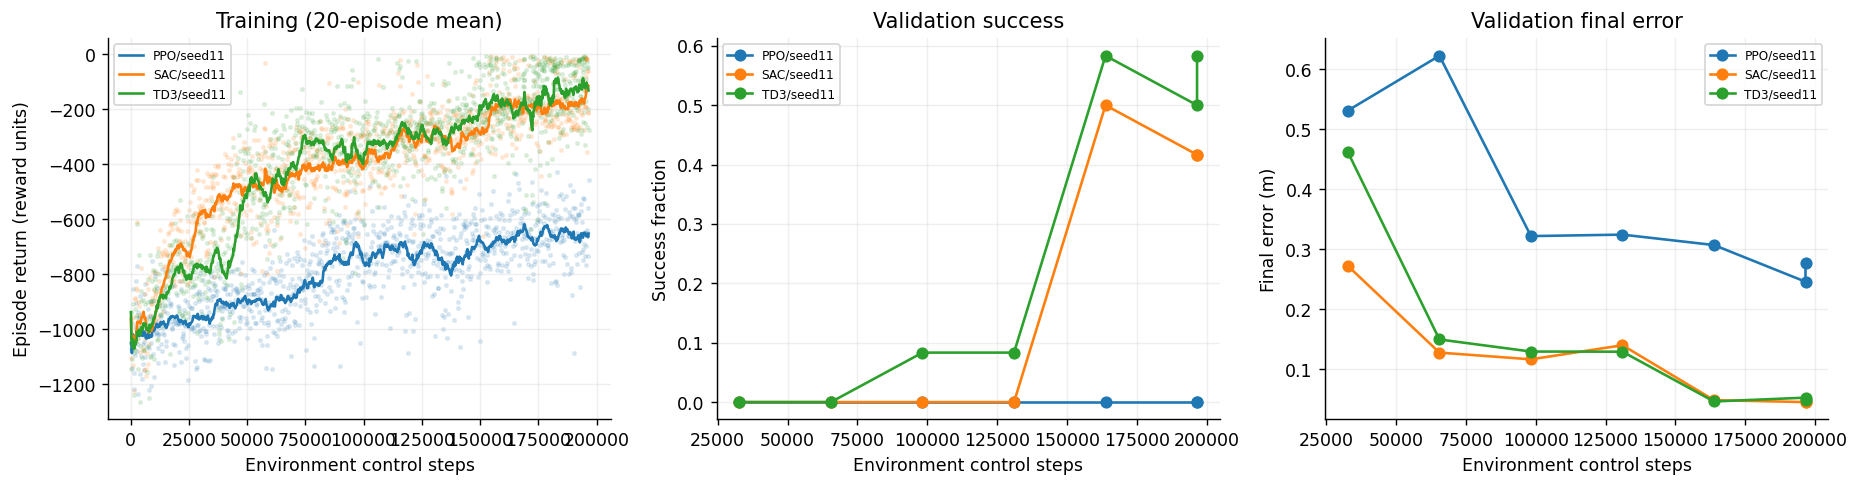

Policies frozen. No more learning or selection below this line.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
for label,run in FINAL_RUNS.items():
    ep=pd.read_csv(run["folder"]/"episodes.csv"); val=pd.read_csv(run["folder"]/"validation.csv")
    axes[0].scatter(ep.timesteps,ep.episode_return,s=4,alpha=.12)
    axes[0].plot(ep.timesteps,ep.episode_return.rolling(20,min_periods=1).mean(),label=label)
    axes[1].plot(val.timesteps,val.success,marker="o",label=label)
    axes[2].plot(val.timesteps,val.final_error,marker="o",label=label)
for ax,title,ylabel in zip(axes,["Training (20-episode mean)","Validation success","Validation final error"],
                           ["Episode return (reward units)","Success fraction","Final error (m)"]):
    ax.set(title=title,xlabel="Environment control steps",ylabel=ylabel); ax.legend(fontsize=7)
fig.tight_layout(); fig.savefig(RUN/"learning_curves.png"); plt.show()
FROZEN_RUNS={**FINAL_RUNS,**ABLATIONS,**OBS_RUNS}
freeze={"pd_gain":PD_GAIN,"ablation_algorithm":ABLATION_ALGO,"policies":{
    label:{"sha256":hashlib.sha256((run["folder"]/"best.zip").read_bytes()).hexdigest(),
           "folder":str(run["folder"]),"selection_key":run["key"],"spec":run["spec"]}
    for label,run in FROZEN_RUNS.items()}}
if (RUN/"freeze.json").exists():
    assert json.loads((RUN/"freeze.json").read_text())==json.loads(json.dumps(freeze)), "Frozen policies changed; use a fresh experimental protocol"
else: save_json(RUN/"freeze.json",freeze)
print("Policies frozen. No more learning or selection below this line.")


## 11 · One held-out test campaign

Nominal evaluation uses 48 targets in STANDARD. The first 16, predeclared before testing, are paired across robustness conditions to bound runtime. Each condition gets a **fresh model**, resets all nominal parameters, changes exactly the selected factor, and verifies the changed fields. Mass and inertia scale together at fixed geometry; payload is a 3 cm inertial sphere, not an obstacle. Damping and friction are independent factors. Each frozen policy is evaluated without adaptation, retraining or perturbed observations containing parameter values.


In [13]:
assert (RUN/"freeze.json").exists()
TEST=target_bank(CFG["test_n"],CFG["split_seeds"]["test"])
for bank in (TRAIN,VAL): assert not set(map(tuple,bank["q"])) & set(map(tuple,TEST["q"]))
np.savez_compressed(RUN/"targets_test.npz",**TEST)
save_json(RUN/"splits.json",{name:{"seed":b["seed"],"count":len(b["p"]),
          "q_sha256":hashlib.sha256(b["q"].tobytes()).hexdigest()} for name,b in [("train",TRAIN),("validation",VAL),("test",TEST)]})

def cached_evaluate(label,controller,run=None,factor="nominal",value=1.,n=None):
    spec={"freeze":digest(freeze),"label":label,"factor":factor,"value":value,"n":n or len(TEST["p"])}
    path=RUN/("evaluation_"+digest(spec)+".csv")
    if path.exists(): return pd.read_csv(path)
    df,_=evaluate(controller,TEST,label,factor,value,n,
        weights=run["spec"]["weights"] if run else None,
        include_error=run["spec"]["include_error"] if run else True)
    df["training_seed"]=run["spec"]["seed"] if run else -1
    df["algorithm"]=run["name"] if run else "PD"
    tmp=path.with_suffix(".tmp"); df.to_csv(tmp,index=False); tmp.replace(path)
    return df

PD=PDController(PD_GAIN)
nominal_frames=[cached_evaluate("PD",PD)]
for label,run in FROZEN_RUNS.items(): nominal_frames.append(cached_evaluate(label,run["model"],run))
ALL_NOMINAL=pd.concat(nominal_frames,ignore_index=True)
ALL_NOMINAL.to_csv(RUN/"nominal_all.csv",index=False)
NOMINAL=ALL_NOMINAL[ALL_NOMINAL.controller.isin(["PD"]+list(FINAL_RUNS))].copy()
print("Nominal episodes:",len(ALL_NOMINAL),"Numerical failures:",ALL_NOMINAL.numerical_failure.sum())
conditions=[(f,v) for f,values in CFG["perturbations"].items() for v in values]
robust_frames=[]; physics_audit={}
for factor,value in conditions:
    audit_model=make_model(); manager=Dynamics(audit_model)
    physics_audit[f"{factor}:{value:g}"]=manager.apply(factor,value)
    manager.apply()
    for k,v in manager.nominal.items(): assert np.array_equal(getattr(audit_model,k),v)
    robust_frames.append(cached_evaluate("PD",PD,factor=factor,value=value,n=CFG["robust_n"]))
    for label,run in FINAL_RUNS.items():
        robust_frames.append(cached_evaluate(label,run["model"],run,factor,value,CFG["robust_n"]))
    print("Completed zero-shot condition",factor,value)
ROBUST=pd.concat(robust_frames,ignore_index=True)
ROBUST.to_csv(RUN/"robustness.csv",index=False); save_json(RUN/"physics_audit.json",physics_audit)
for label,run in FROZEN_RUNS.items():
    assert hashlib.sha256((run["folder"]/"best.zip").read_bytes()).hexdigest()==freeze["policies"][label]["sha256"]


Nominal episodes: 336 Numerical failures: 0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Completed zero-shot condition mass 0.8


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Completed zero-shot condition mass 0.9


...

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Completed zero-shot condition strength 1.1


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Completed zero-shot condition strength 1.2


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 12 · Uncertainty and paired effects

Wilson intervals describe binary episode success. Nonparametric bootstrap intervals describe means, conditional on a fixed trained policy and this target distribution. Paired bootstrap differences resample **target IDs**, preserving common targets across controllers and dynamics conditions. Intervals are descriptive and not corrected for many comparisons. Failed time-to-target is missing, not zero. Capped time retains failures, and success-conditioned time may misleadingly favor a controller that succeeds only on easy targets.

One training seed cannot estimate algorithm-level training variability. If multiple seeds are configured, summaries remain separated by training seed; these episode intervals do not pool seed variation. Paired comparisons use equal configured seed IDs. Small differences with overlapping or wide intervals should not support strong rankings. Bootstrap intervals can collapse when all sampled differences are identical, especially in QUICK; zero width is not proof of population certainty.


In [14]:
def bootstrap_mean(values,seed=404,reps=2000):
    x=np.asarray(values,dtype=float); x=x[np.isfinite(x)]
    if not len(x): return (np.nan,np.nan,np.nan)
    rng=np.random.default_rng(seed); means=x[rng.integers(len(x),size=(reps,len(x)))].mean(axis=1)
    return float(x.mean()),float(np.quantile(means,.025)),float(np.quantile(means,.975))
def wilson(x):
    n=len(x); p=np.mean(x); z=1.95996398454; denom=1+z*z/n
    center=(p+z*z/(2*n))/denom; half=z*np.sqrt(p*(1-p)/n+z*z/(4*n*n))/denom
    return p,center-half,center+half
METRICS=["success","final_error","time_to_target","capped_time","effort","effort_rate","work",
         "smoothness","smoothness_rate","trajectory_length","violations","collisions","episode_return"]
def summarize(df):
    rows=[]
    for label,group in df.groupby("controller"):
        for metric in METRICS:
            mean,lo,hi=wilson(group[metric]) if metric=="success" else bootstrap_mean(group[metric])
            rows.append({"controller":label,"metric":metric,"mean":mean,"ci_low":lo,"ci_high":hi,
                         "std":group[metric].std(),"median":group[metric].median(),"n":group[metric].notna().sum()})
    return pd.DataFrame(rows)
SUMMARY=summarize(NOMINAL); SUMMARY.to_csv(RUN/"nominal_statistics.csv",index=False)
display(SUMMARY)

paired=[]
reference=NOMINAL[NOMINAL.controller=="PD"]
for label in FINAL_RUNS:
    merged=NOMINAL[NOMINAL.controller==label].merge(reference,on="target_index",suffixes=("_rl","_pd"),validate="one_to_one")
    for metric in ["success","final_error","effort_rate","smoothness_rate","capped_time"]:
        mean,lo,hi=bootstrap_mean(merged[metric+"_rl"]-merged[metric+"_pd"])
        paired.append({"controller":label,"reference":"PD","metric":metric,"difference":mean,"ci_low":lo,"ci_high":hi})
PAIRED=pd.DataFrame(paired); PAIRED.to_csv(RUN/"paired_rl_minus_pd.csv",index=False)
display(PAIRED)
degradation=[]
for (label,factor,value),group in ROBUST.groupby(["controller","factor","value"]):
    base=NOMINAL[(NOMINAL.controller==label)&(NOMINAL.target_index<CFG["robust_n"])]
    pair=group.merge(base,on="target_index",suffixes=("_shift","_base"),validate="one_to_one")
    for metric in ["success","final_error","time_to_target","capped_time","effort_rate","smoothness_rate","episode_return"]:
        mean,lo,hi=bootstrap_mean(pair[metric+"_shift"]-pair[metric+"_base"])
        base_mean=pair[metric+"_base"].mean()
        degradation.append({"controller":label,"factor":factor,"value":value,"metric":metric,
            "delta":mean,"ci_low":lo,"ci_high":hi,"nominal_mean":base_mean,
            "relative_delta":mean/abs(base_mean) if abs(base_mean)>1e-8 else np.nan})
DEGRADATION=pd.DataFrame(degradation); DEGRADATION.to_csv(RUN/"robustness_degradation.csv",index=False)


,controller,metric,mean,ci_low,ci_high,std,median,n
0,PD,success,1.000000,0.925900,1.000000,0.000000,1.000000,48
1,PD,final_error,0.011838,0.010502,0.013232,0.005030,0.011818,48
2,PD,time_to_target,0.730000,0.691250,0.773760,0.146215,0.720000,48
3,PD,capped_time,0.730000,0.691250,0.773760,0.146215,0.720000,48
4,PD,effort,495.797983,443.725279,567.041592,220.035313,434.017058,48
5,PD,effort_rate,664.539648,630.909471,705.092662,137.776606,633.462199,48
6,PD,work,9.879470,7.792402,12.790104,8.720952,9.352789,48
7,PD,smoothness,1.259353,0.962426,1.645227,1.191086,0.952920,48
8,PD,smoothness_rate,0.033008,0.026293,0.041319,0.026000,0.028293,48
9,PD,trajectory_length,0.210218,0.183711,0.237680,0.096694,0.191241,48


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,controller,reference,metric,difference,ci_low,ci_high
0,PPO/seed11,PD,success,-1.000000,-1.000000,-1.000000
1,PPO/seed11,PD,final_error,0.193936,0.171959,0.217353
2,PPO/seed11,PD,effort_rate,18094.261182,17808.840155,18387.758009
3,PPO/seed11,PD,smoothness_rate,0.060054,0.052037,0.067233
4,PPO/seed11,PD,capped_time,3.270000,3.226240,3.308750
5,SAC/seed11,PD,success,-0.687500,-0.812500,-0.562500
6,SAC/seed11,PD,final_error,0.037512,0.029879,0.045456
7,SAC/seed11,PD,effort_rate,3096.306450,2450.628930,3823.742004
8,SAC/seed11,PD,smoothness_rate,1.751014,1.386333,2.172077
9,SAC/seed11,PD,capped_time,2.422083,2.052427,2.789177


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

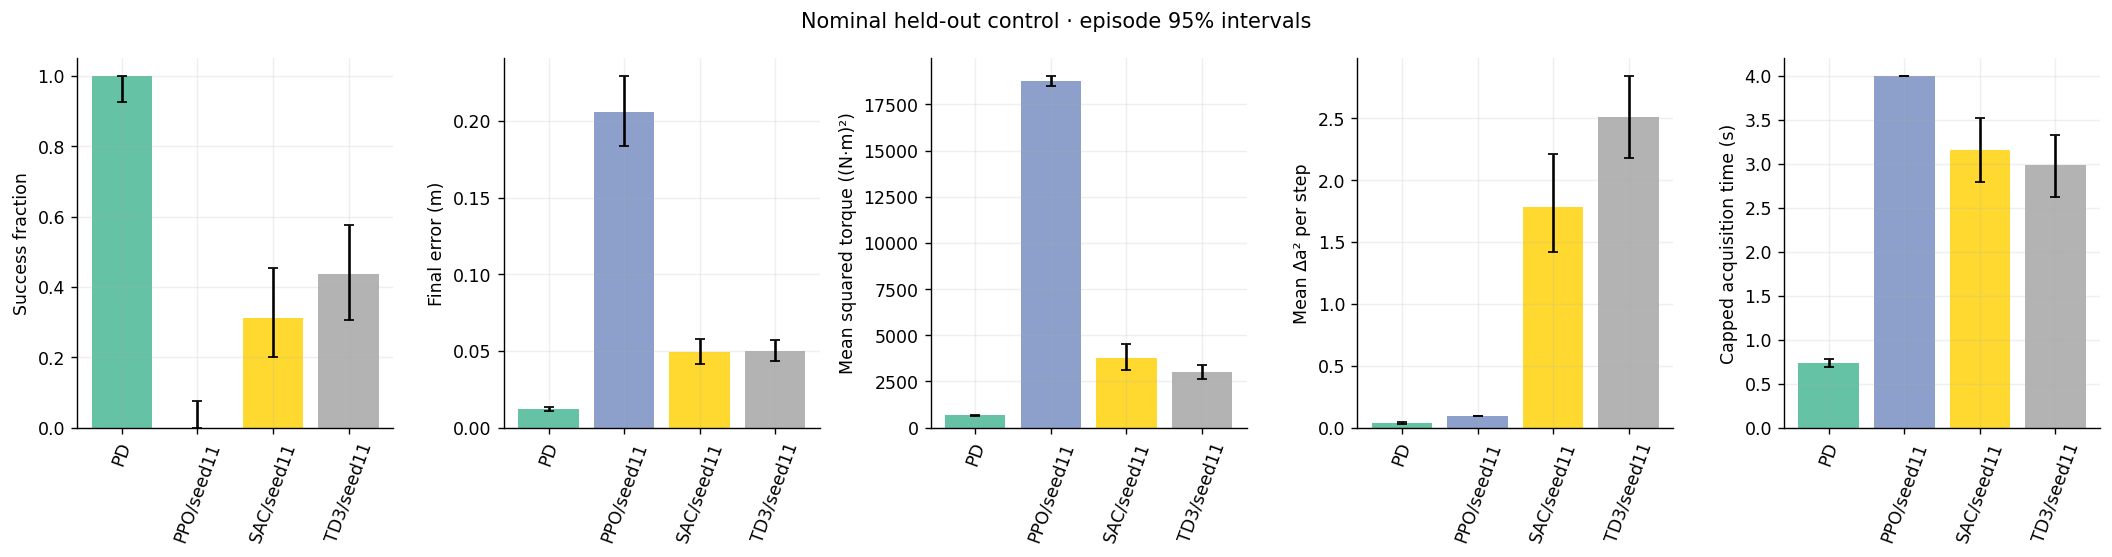

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


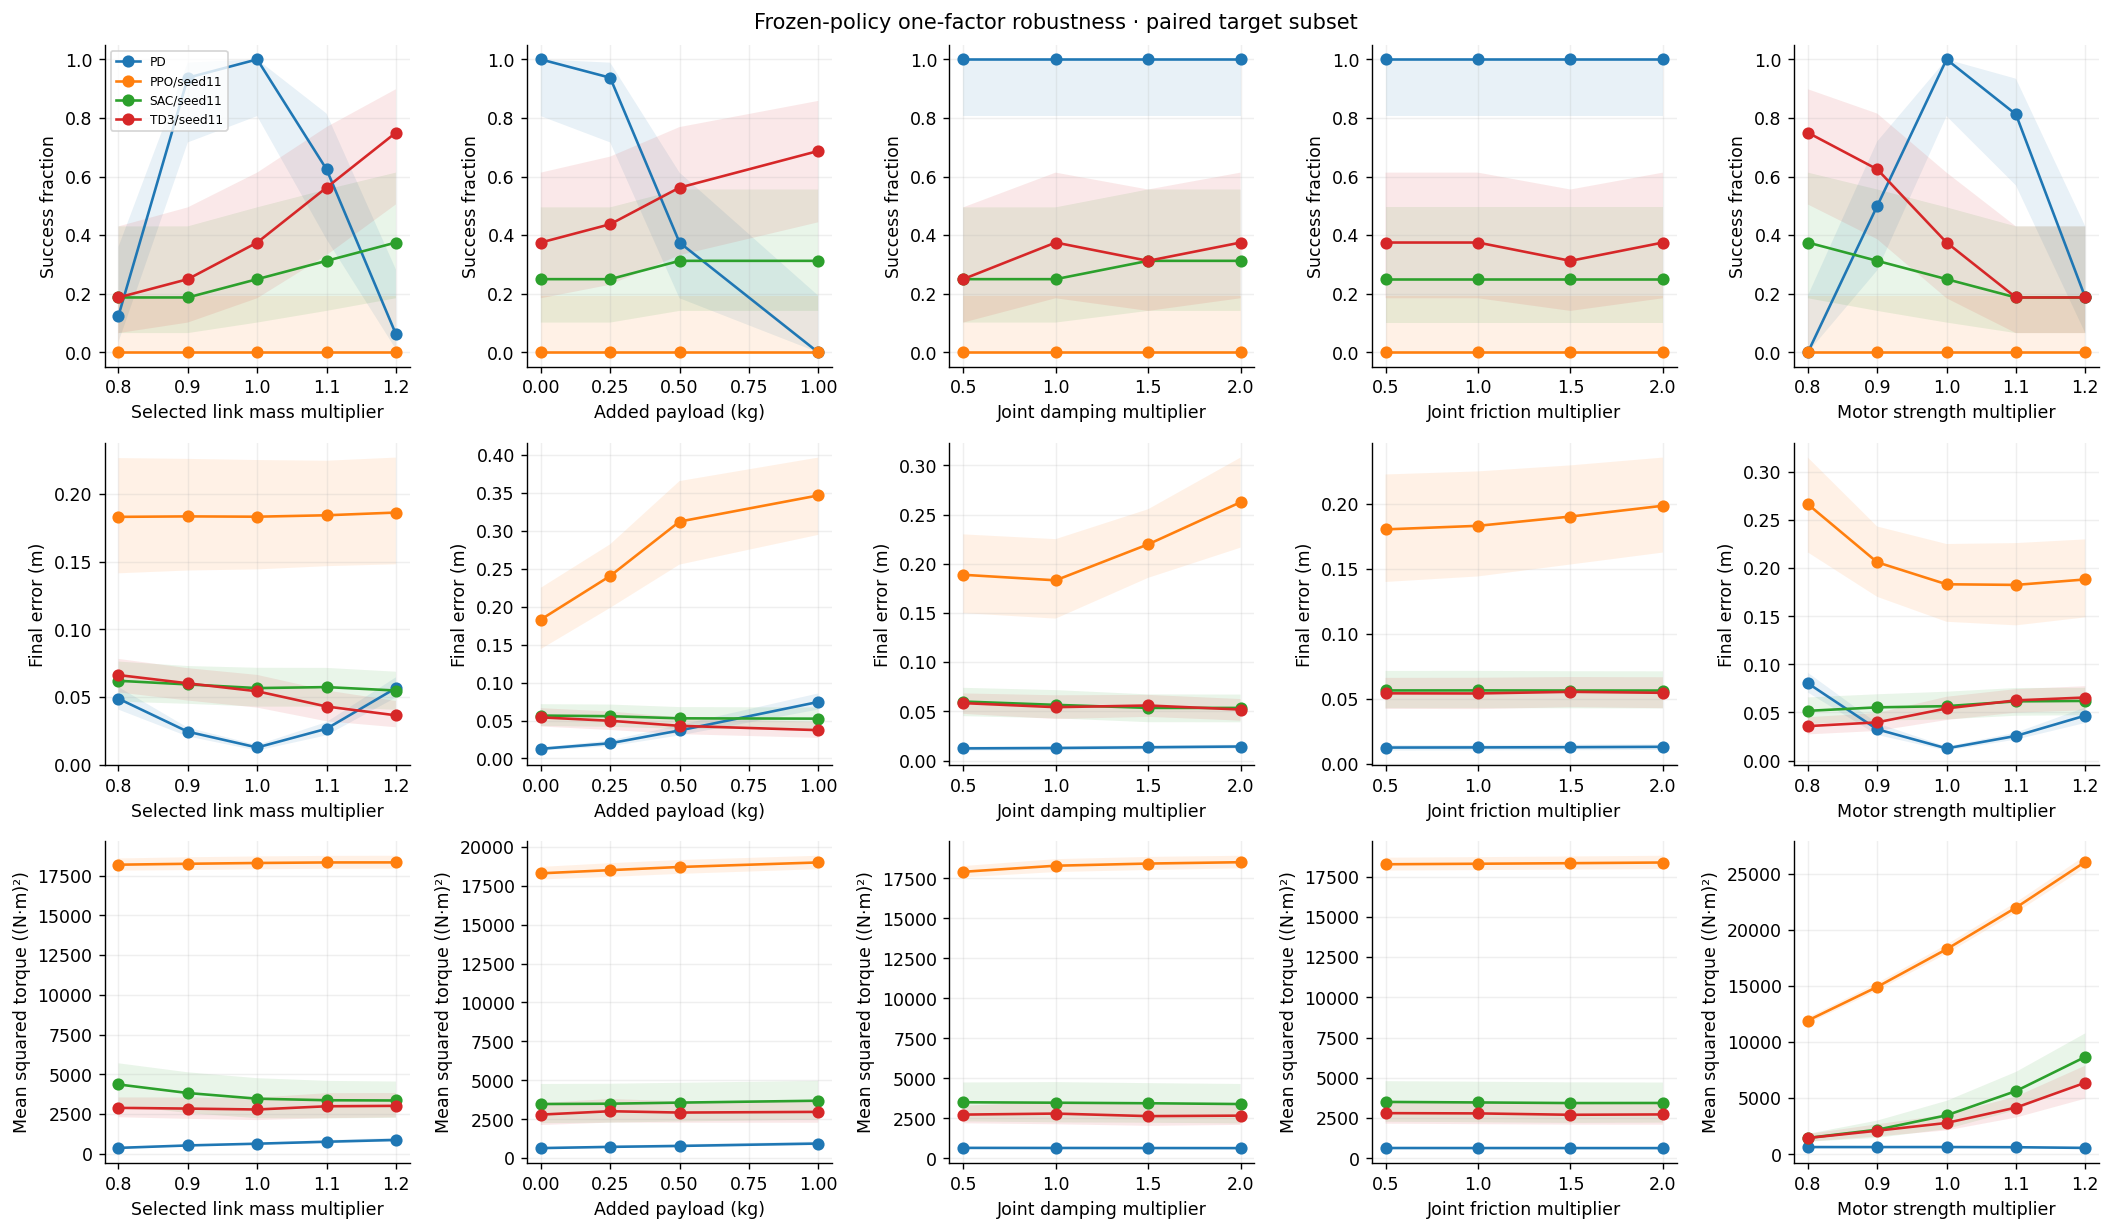

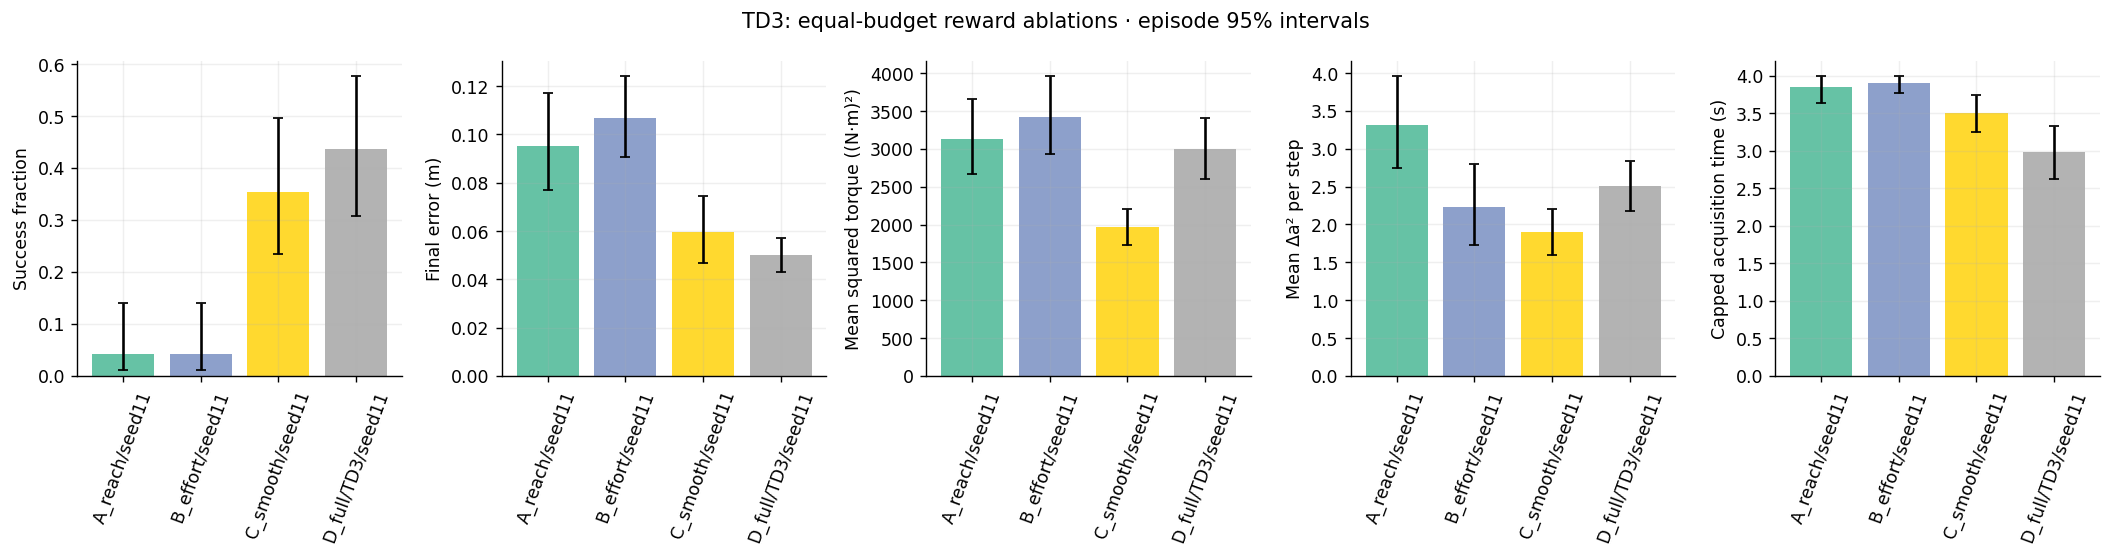

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,seed,contrast,metric,delta,ci_low,ci_high
0,11,B_effort minus A_reach,success,0.000000,-0.083333,0.083333
1,11,B_effort minus A_reach,final_error,0.011375,-0.012104,0.032828
2,11,B_effort minus A_reach,effort_rate,294.837453,-516.123176,1044.482170
3,11,B_effort minus A_reach,smoothness_rate,-1.081295,-2.060083,-0.138153
4,11,B_effort minus A_reach,capped_time,0.057500,-0.173750,0.320833
5,11,C_smooth minus B_effort,success,0.312500,0.166667,0.458333
6,11,C_smooth minus B_effort,final_error,-0.047340,-0.063563,-0.030253
7,11,C_smooth minus B_effort,effort_rate,-1463.862742,-1990.011366,-974.201179
8,11,C_smooth minus B_effort,smoothness_rate,-0.335180,-1.016082,0.317315
9,11,C_smooth minus B_effort,capped_time,-0.400417,-0.633771,-0.167865


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [15]:
def comparison_plot(frame,filename,title):
    stats=summarize(frame); fig,axes=plt.subplots(1,5,figsize=(17,4.5))
    choices=[("success","Success fraction"),("final_error","Final error (m)"),
             ("effort_rate","Mean squared torque ((N·m)²)"),("smoothness_rate","Mean Δa² per step"),
             ("capped_time","Capped acquisition time (s)")]
    for ax,(metric,ylabel) in zip(axes,choices):
        sub=stats[stats.metric==metric]
        ax.bar(sub.controller,sub["mean"],color=plt.cm.Set2(np.linspace(0,1,len(sub))))
        ax.errorbar(np.arange(len(sub)),sub["mean"],yerr=np.maximum(0,np.vstack([sub["mean"]-sub.ci_low,sub.ci_high-sub["mean"]])),fmt="none",color="black",capsize=3)
        ax.set(ylabel=ylabel); ax.tick_params(axis="x",labelrotation=70)
    fig.suptitle(title+" · episode 95% intervals"); fig.tight_layout(); fig.savefig(RUN/filename); plt.show()
comparison_plot(NOMINAL,"algorithm_comparison.png","Nominal held-out control")

fig,axes=plt.subplots(3,5,figsize=(17,10))
factor_units={"mass":"Selected link mass multiplier","payload":"Added payload (kg)",
              "damping":"Joint damping multiplier","friction":"Joint friction multiplier","strength":"Motor strength multiplier"}
for col,(factor,xlabel) in enumerate(factor_units.items()):
    for row,(metric,ylabel) in enumerate([("success","Success fraction"),("final_error","Final error (m)"),
                                         ("effort_rate","Mean squared torque ((N·m)²)")]):
        ax=axes[row,col]
        for label in NOMINAL.controller.unique():
            base=NOMINAL[(NOMINAL.controller==label)&(NOMINAL.target_index<CFG["robust_n"])]
            interval=wilson if metric=="success" else bootstrap_mean
            values=[(0. if factor=="payload" else 1.,interval(base[metric]))]
            for v,g in ROBUST[(ROBUST.controller==label)&(ROBUST.factor==factor)].groupby("value"):
                values.append((v,interval(g[metric])))
            values.sort(); x=np.array([v[0] for v in values]); y=np.array([v[1] for v in values])
            ax.plot(x,y[:,0],"o-",label=label); ax.fill_between(x,y[:,1],y[:,2],alpha=.1)
        ax.set(xlabel=xlabel,ylabel=ylabel)
axes[0,0].legend(fontsize=7); fig.suptitle("Frozen-policy one-factor robustness · paired target subset")
fig.tight_layout(); fig.savefig(RUN/"robustness_curves.png"); plt.show()

ablation_labels=list(ABLATIONS)+[label for label,r in FINAL_RUNS.items() if r["name"]==ABLATION_ALGO]
AB_RESULTS=ALL_NOMINAL[ALL_NOMINAL.controller.isin(ablation_labels)].copy()
AB_RESULTS["controller"]=AB_RESULTS.controller.map(lambda x:x if x in ABLATIONS else "D_full/"+x)
AB_RESULTS.to_csv(RUN/"ablation_episodes.csv",index=False)
comparison_plot(AB_RESULTS,"reward_ablation.png",f"{ABLATION_ALGO}: equal-budget reward ablations")
ablation_pairs=[]
for seed in CFG["training_seeds"]:
    for before,after in [("A_reach","B_effort"),("B_effort","C_smooth")]:
        left=ALL_NOMINAL[ALL_NOMINAL.controller==f"{before}/seed{seed}"]
        right=ALL_NOMINAL[ALL_NOMINAL.controller==f"{after}/seed{seed}"]
        pair=right.merge(left,on="target_index",suffixes=("_after","_before"),validate="one_to_one")
        for metric in ["success","final_error","effort_rate","smoothness_rate","capped_time"]:
            mean,lo,hi=bootstrap_mean(pair[metric+"_after"]-pair[metric+"_before"])
            ablation_pairs.append({"seed":seed,"contrast":f"{after} minus {before}","metric":metric,"delta":mean,"ci_low":lo,"ci_high":hi})
AB_EFFECTS=pd.DataFrame(ablation_pairs); AB_EFFECTS.to_csv(RUN/"ablation_paired_effects.csv",index=False); display(AB_EFFECTS)
if OBS_RUNS:
    obs_labels=list(OBS_RUNS)+[k for k,r in FINAL_RUNS.items() if r["name"]==ABLATION_ALGO]
    comparison_plot(ALL_NOMINAL[ALL_NOMINAL.controller.isin(obs_labels)],"observation_ablation.png","Explicit error-vector ablation")


## 13 · Joint traces and evaluation-only videos

Target index **0** and the first configured training seed were fixed in advance. Show all four controllers, including failures. A payload example uses the validation-selected algorithm and +0.5 kg, regardless of how impressive the video looks. The target appears as a translucent red sphere. Plotted torques are the mean applied torque within each 20 ms control interval. Video rendering occurs only here; rendering errors are saved and surfaced, while numerical experiment results remain available.


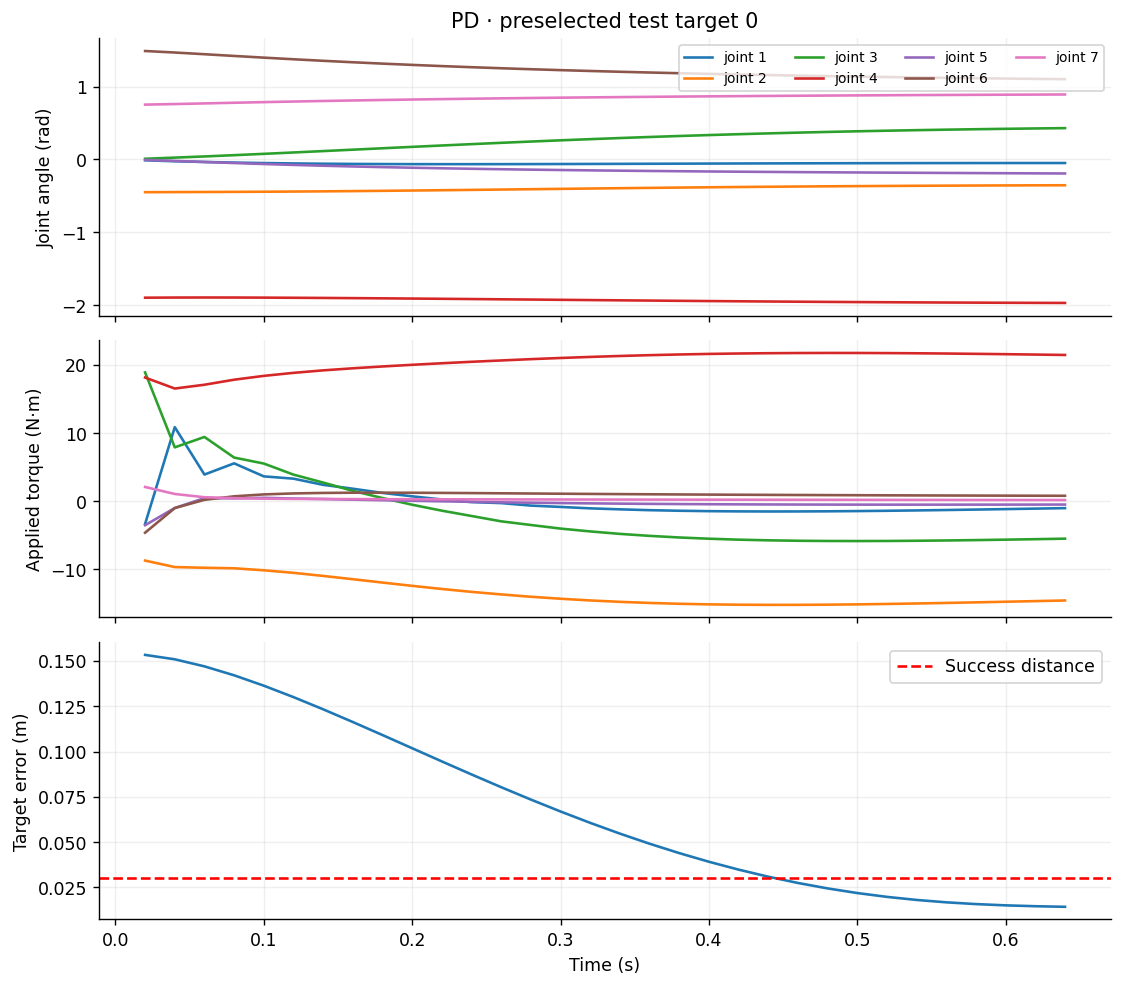

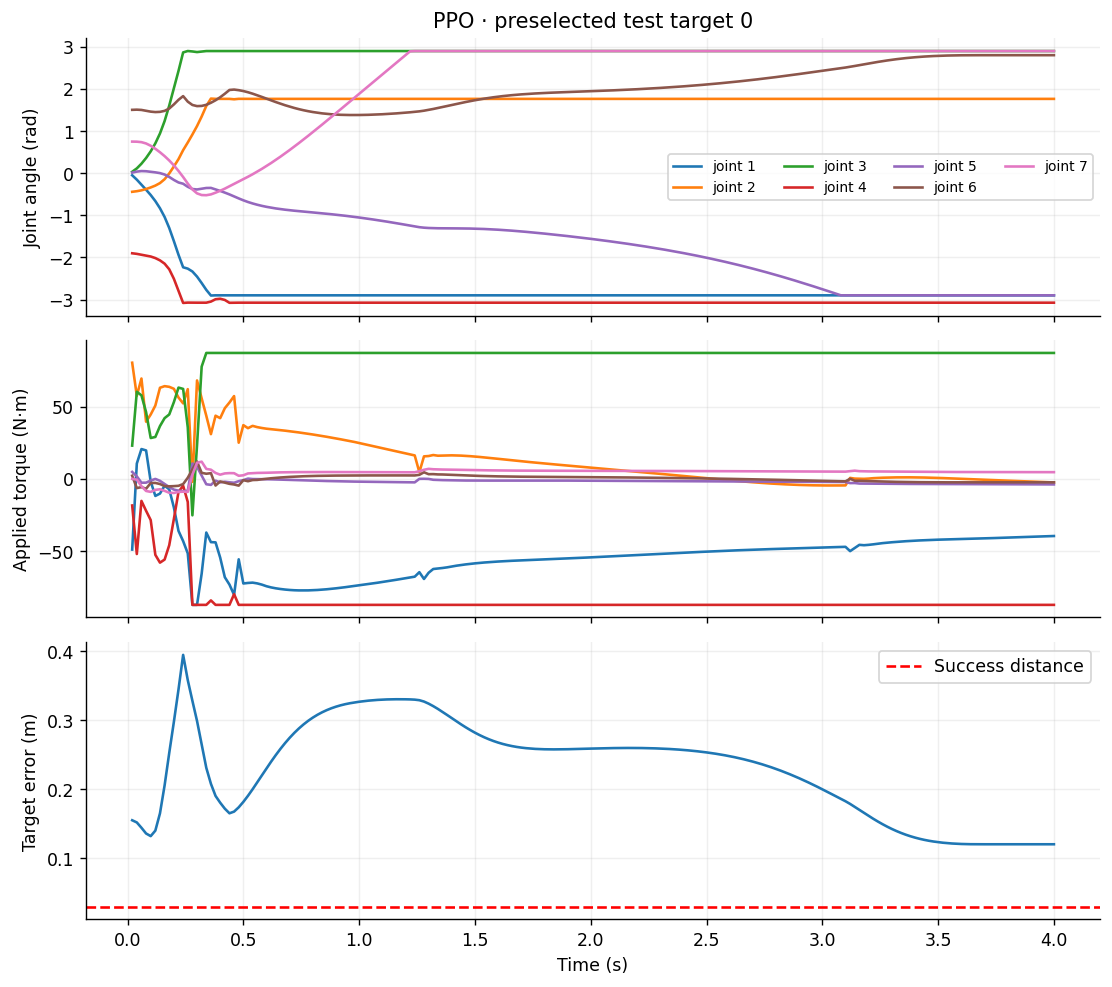

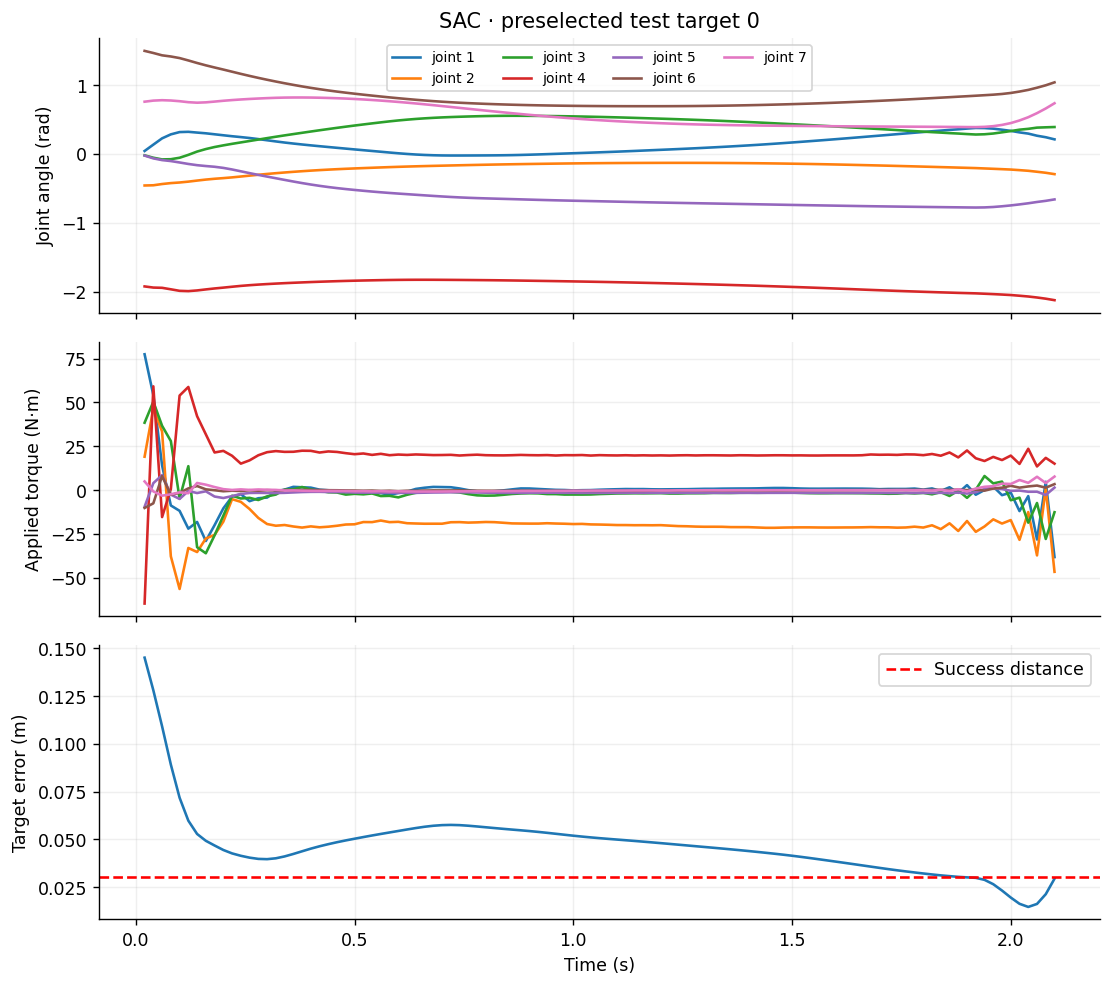

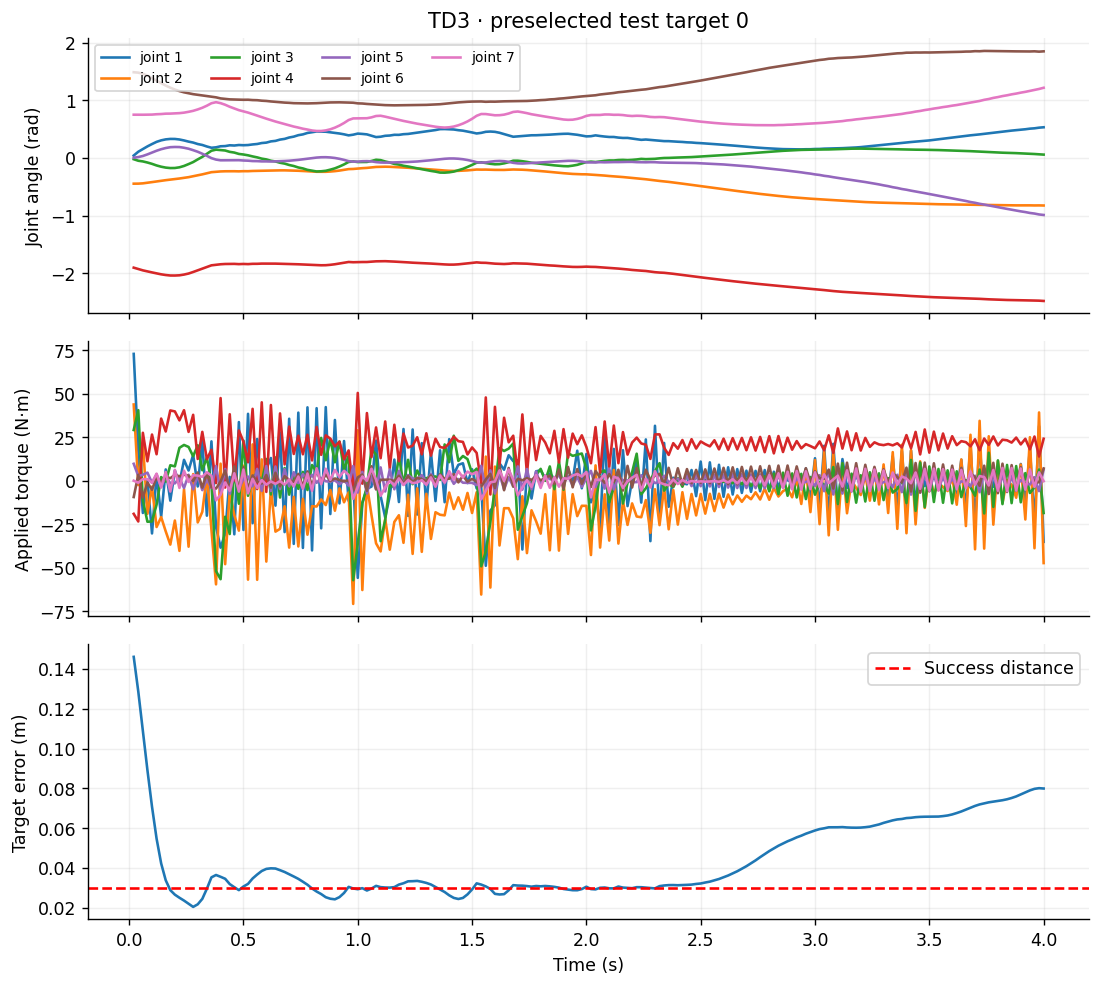

**PD — target 0; nominal=1**

**PPO — target 0; nominal=1**

**SAC — target 0; nominal=1**

**TD3 — target 0; nominal=1**

**TD3_payload — target 0; payload=0.5**

In [16]:
REPRESENTATIVES={"PD":PD}
for name in ALGOS: REPRESENTATIVES[name]=FINAL_RUNS[f"{name}/seed{CFG['training_seeds'][0]}"]["model"]
for label,controller in REPRESENTATIVES.items():
    _,traces=evaluate(controller,TEST,label,n=1,trace=True)
    tr=traces[0]; t=np.array([x["t"] for x in tr]); q=np.array([x["q"] for x in tr]); tau=np.array([x["tau"] for x in tr])
    fig,axes=plt.subplots(3,1,figsize=(9,8),sharex=True)
    for j in range(7):
        axes[0].plot(t,q[:,j],label=f"joint {j+1}")
        axes[1].plot(t,tau[:,j])
    axes[2].plot(t,[x["error"] for x in tr]); axes[2].axhline(CFG["tolerance"],ls="--",color="red",label="Success distance")
    axes[0].set(ylabel="Joint angle (rad)",title=f"{label} · preselected test target 0"); axes[0].legend(ncol=4,fontsize=8)
    axes[1].set(ylabel="Applied torque (N·m)"); axes[2].set(ylabel="Target error (m)",xlabel="Time (s)"); axes[2].legend()
    fig.tight_layout(); fig.savefig(RUN/f"trace_{label}.png"); plt.show()
    np.savez_compressed(RUN/f"trace_{label}.npz",t=t,q=q,tau=tau,error=[x["error"] for x in tr])

video_status=[]
for label,controller,factor,value in [(k,v,"nominal",1.) for k,v in REPRESENTATIVES.items()]+[
        (ABLATION_ALGO+"_payload",REPRESENTATIVES[ABLATION_ALGO],"payload",.5)]:
    path=RUN/f"video_{label}.mp4"
    try:
        evaluate(controller,TEST,label,factor,value,n=1,video_path=path)
        display(Markdown(f"**{label} — target 0; {factor}={value:g}**")); display(Video(str(path),embed=True,width=640))
        video_status.append({"name":label,"status":"saved","path":str(path)})
    except Exception as exc:
        video_status.append({"name":label,"status":"failed","error":repr(exc)})
        print("RENDER FAILED:",label,repr(exc),". On Colab rerun in a fresh runtime with MUJOCO_GL=osmesa set before imports.")
save_json(RUN/"video_status.json",video_status)


## 14 · Final measured comparison and interpretation

The table below is populated only by the executed evaluations. Robustness is the worst **paired success change** across the specified shifts (percentage points); it is not an all-purpose robustness score. Main time-to-target is success-conditioned; `capped_time` and counts remain in CSVs. Episode uncertainty is conditional on each trained seed. There is no predetermined winner.


In [17]:
def fmt_ci(group,metric,percent=False):
    mean,lo,hi=wilson(group[metric]) if metric=="success" else bootstrap_mean(group[metric])
    if not np.isfinite(mean): return "— (no successes)"
    scale=100 if percent else 1
    return f"{mean*scale:.3g} [{lo*scale:.3g}, {hi*scale:.3g}]"
table=[]
for label,g in NOMINAL.groupby("controller"):
    worst=DEGRADATION[(DEGRADATION.controller==label)&(DEGRADATION.metric=="success")].delta.min()
    table.append({"Controller":label,"Success % [95% CI]":fmt_ci(g,"success",True),
        "Final error m [CI]":fmt_ci(g,"final_error"),"Median error m":g.final_error.median(),
        "Time to target s [CI]":fmt_ci(g,"time_to_target"),
        "Effort (Nm)²s [CI]":fmt_ci(g,"effort"),"Mean Δa²/step [CI]":fmt_ci(g,"smoothness_rate"),
        "Worst Δsuccess pp":100*worst})
FINAL_TABLE=pd.DataFrame(table); FINAL_TABLE.to_csv(RUN/"final_comparison.csv",index=False); display(FINAL_TABLE)
means=NOMINAL.groupby("controller")[["success","final_error","effort_rate","smoothness_rate"]].mean()
sentences=[f"**{MODE} measured results.** Episode intervals describe target variation, not training-seed uncertainty."]
for label,row in means.iterrows():
    sentences.append(f"{label}: success {row.success:.1%}, mean final error {row.final_error:.3f} m, "
        f"mean squared torque {row.effort_rate:.1f} (N·m)², action variation {row.smoothness_rate:.3f} per step.")
sentences.append(f"Highest observed success: {means.success.idxmax()}. Lowest observed effort rate: "
                 f"{means.effort_rate.idxmin()}. Lowest action variation: {means.smoothness_rate.idxmin()}. "
                 "These point-estimate rankings do not establish statistical superiority.")
for _,r in PAIRED[PAIRED.metric.isin(["success","final_error"])].iterrows():
    sentences.append(f"{r.controller} minus PD, {r.metric}: {r.difference:+.3f} "
                     f"(paired 95% interval {r.ci_low:+.3f} to {r.ci_high:+.3f}).")
for label in means.index:
    sub=DEGRADATION[(DEGRADATION.controller==label)&(DEGRADATION.metric=="success")]
    worst=sub.loc[sub.delta.idxmin()]
    sentences.append(f"{label}'s largest observed success drop: {worst.factor}={worst.value:g}, "
                     f"{100*worst.delta:+.1f} percentage points relative to the same nominal targets.")
for _,r in AB_EFFECTS.iterrows():
    if r.metric in ["success","final_error","effort_rate","smoothness_rate"]:
        sentences.append(f"Ablation seed {r.seed}, {r.contrast}, {r.metric}: {r.delta:+.4g} "
            f"[{r.ci_low:+.4g}, {r.ci_high:+.4g}].")
sentences.append("Interpret effort reductions jointly with success and error: a stationary failed arm can look cheap. "
    "An effort decrease accompanied by an error increase is evidence of a measured tradeoff; a smoothness decrease "
    "without a success decrease is more encouraging, but finite-episode and training uncertainty remain. "
    "A→B and B→C contrasts test the added terms only under this chosen training setup.")
if means.success.max()<.5: sentences.append("No controller exceeded 50% success: this run does not establish reliable reaching.")
if MODE=="QUICK": sentences.append("QUICK is a debugging run: none of these rankings should be presented as a portfolio research conclusion.")
discussion="\n\n".join(sentences)
display(Markdown(discussion)); (RUN/"measured_discussion.md").write_text(discussion)


,Controller,Success % [95% CI],Final error m [CI],Median error m,Time to target s [CI],Effort (Nm)²s [CI],Mean Δa²/step [CI],Worst Δsuccess pp
0,PD,"100 [92.6, 100]","0.0118 [0.0105, 0.0132]",0.011818,"0.73 [0.691, 0.774]","496 [444, 567]","0.033 [0.0263, 0.0413]",-100.00
1,PPO/seed11,"0 [0, 7.41]","0.206 [0.184, 0.229]",0.199459,— (no successes),"7.5e+04 [7.39e+04, 7.62e+04]","0.0931 [0.0895, 0.0964]",0.00
2,SAC/seed11,"31.2 [19.9, 45.3]","0.0494 [0.0413, 0.0577]",0.049349,"1.29 [0.859, 1.76]","1.18e+04 [9.18e+03, 1.48e+04]","1.78 [1.42, 2.21]",-6.25
3,TD3/seed11,"43.8 [30.7, 57.7]","0.0501 [0.0432, 0.0572]",0.052253,"1.68 [1.32, 2.03]","8.25e+03 [6.92e+03, 9.7e+03]","2.51 [2.18, 2.84]",-18.75


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**STANDARD measured results.** Episode intervals describe target variation, not training-seed uncertainty.

PD: success 100.0%, mean final error 0.012 m, mean squared torque 664.5 (N·m)², action variation 0.033 per step.

PPO/seed11: success 0.0%, mean final error 0.206 m, mean squared torque 18758.8 (N·m)², action variation 0.093 per step.

SAC/seed11: success 31.2%, mean final error 0.049 m, mean squared torque 3760.8 (N·m)², action variation 1.784 per step.

TD3/seed11: success 43.8%, mean final error 0.050 m, mean squared torque 2997.6 (N·m)², action variation 2.507 per step.

Highest observed success: PD. Lowest observed effort rate: PD. Lowest action variation: PD. These point-estimate rankings do not establish statistical superiority.

PPO/seed11 minus PD, success: -1.000 (paired 95% interval -1.000 to -1.000).

PPO/seed11 minus PD, final_error: +0.194 (paired 95% interval +0.172 to +0.217).

SAC/seed11 minus PD, success: -0.688 (paired 95% interval -0.812 to -0.562).

SAC/seed11 minus PD, final_error: +0.038 (paired 95% interval +0.030 to +0.045).

TD3/seed11 minus PD, success: -0.562 (paired 95% interval -0.688 to -0.417).

TD3/seed11 minus PD, final_error: +0.038 (paired 95% interval +0.032 to +0.045).

PD's largest observed success drop: payload=1, -100.0 percentage points relative to the same nominal targets.

PPO/seed11's largest observed success drop: damping=0.5, +0.0 percentage points relative to the same nominal targets.

SAC/seed11's largest observed success drop: mass=0.8, -6.2 percentage points relative to the same nominal targets.

TD3/seed11's largest observed success drop: mass=0.8, -18.8 percentage points relative to the same nominal targets.

Ablation seed 11, B_effort minus A_reach, success: +0 [-0.08333, +0.08333].

Ablation seed 11, B_effort minus A_reach, final_error: +0.01138 [-0.0121, +0.03283].

Ablation seed 11, B_effort minus A_reach, effort_rate: +294.8 [-516.1, +1044].

Ablation seed 11, B_effort minus A_reach, smoothness_rate: -1.081 [-2.06, -0.1382].

Ablation seed 11, C_smooth minus B_effort, success: +0.3125 [+0.1667, +0.4583].

Ablation seed 11, C_smooth minus B_effort, final_error: -0.04734 [-0.06356, -0.03025].

Ablation seed 11, C_smooth minus B_effort, effort_rate: -1464 [-1990, -974.2].

Ablation seed 11, C_smooth minus B_effort, smoothness_rate: -0.3352 [-1.016, +0.3173].

Interpret effort reductions jointly with success and error: a stationary failed arm can look cheap. An effort decrease accompanied by an error increase is evidence of a measured tradeoff; a smoothness decrease without a success decrease is more encouraging, but finite-episode and training uncertainty remain. A→B and B→C contrasts test the added terms only under this chosen training setup.

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


2752

## 15 · What this experiment can and cannot establish

This pipeline tests joint-level control, normalized effort, action smoothness and bounded zero-shot physics changes in one simulated morphology. The **sim-to-real gap** includes unmodeled motor bandwidth, backlash, sensor noise, delays, calibration, thermal limits and contact uncertainty. Do not deploy learned torques to hardware from this notebook.

The task uses a fixed initial pose, local position-only targets and no obstacles beyond robot/floor collision. Target witnesses do not prove a feasible timed trajectory. Reward engineering, short training, a two-point learning-rate search, sparse validation targets, finite dynamics ranges and stochastic training limit conclusions. Action smoothness measures commanded torque changes, not joint jerk or hardware fatigue. Mechanical work excludes electrical losses; squared torque is a proxy. Episode stopping changes effort exposure. One training seed makes conditional policy comparisons possible but cannot establish robust algorithm-level rankings. Failure logs must accompany results; more training is not guaranteed to fix a poor formulation.

The optional observation comparison tests whether explicitly supplying a mathematically redundant error vector helps learning, not whether the robot has gained new sensory information. Robustness tests are one-factor shifts; they do not establish performance under simultaneous unknown changes.

**Future work:** orientation and 6D pose targets, obstacle avoidance, manipulation and grasping, dexterous hands, domain randomization, recurrent policies, tactile/force sensing and carefully validated sim-to-real transfer. These remain extensions, not implemented distractions.

**Conclusion:** use the executed table, paired effects, failures and ablations above to answer the research question. Accurate reaching, lower effort and smooth control must be demonstrated together; no algorithm is assumed to win.

## 16 · Saved artifacts and references

Run the definition/setup cells and training orchestration again to reuse compatible completed checkpoints. Plot/evaluation caches are tied to the frozen policy set. For a surviving Colab session, rerun plotting cells directly. For a new runtime, select the same mounted Drive cache before setup. The run folder contains configurations, source/license hashes, split witnesses, selected models, two recent resume states per run, raw training/reward logs, nominal and robustness episodes, uncertainty, ablations, figures and videos. Copy the whole run and asset directories for offline audit; model XML references its downloaded assets.

Primary references:

* [MuJoCo Menagerie Panda model and license](https://github.com/google-deepmind/mujoco_menagerie/tree/822c2d8f877dd166c5b7d3c9f7e3c3b6589473b7/franka_emika_panda)
* [MuJoCo computation: dynamics, actuation and constraints](https://mujoco.readthedocs.io/en/stable/computation/index.html)
* [MuJoCo model constants and API](https://mujoco.readthedocs.io/en/stable/APIreference/APIfunctions.html#mj-setconst)
* [Gymnasium custom environment API](https://gymnasium.farama.org/introduction/create_custom_env/)
* [SB3 PPO](https://stable-baselines3.readthedocs.io/en/v2.7.1/modules/ppo.html), [SAC](https://stable-baselines3.readthedocs.io/en/v2.7.1/modules/sac.html), [TD3](https://stable-baselines3.readthedocs.io/en/v2.7.1/modules/td3.html), [checkpoint callbacks](https://stable-baselines3.readthedocs.io/en/v2.7.1/guide/callbacks.html)
* [PPO paper](https://arxiv.org/abs/1707.06347), [SAC paper](https://arxiv.org/abs/1801.01290), [TD3 paper](https://arxiv.org/abs/1802.09477)


In [18]:
save_json(RUN/"experiment_complete.json",{"mode":MODE,"freeze_hash":digest(freeze),
    "nominal_rows":len(ALL_NOMINAL),"robustness_rows":len(ROBUST),"videos":video_status,
    "numerical_failures":int(ALL_NOMINAL.numerical_failure.sum()+ROBUST.numerical_failure.sum())})
artifacts=pd.DataFrame([{"file":str(p.relative_to(RUN)),"bytes":p.stat().st_size}
                        for p in RUN.rglob("*") if p.is_file()])
artifacts.to_csv(RUN/"artifact_manifest.csv",index=False)
print("Completed:",RUN); display(artifacts)
# In Colab's Files pane, browse this directory to view/download outputs.
# For persistent reuse, set CACHE_DIR to an already mounted Drive path before the run.


Completed: /content/panda_rl/22d17b54f98f1a8d


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,file,bytes
0,nominal_all.csv,121434
1,evaluation_ae2bcab396536bd7.csv,6156
2,evaluation_be83b45fce787025.csv,6167
3,video_PD.mp4,25080
4,paired_rl_minus_pd.csv,1177
...,...,...
278,pilot_SAC_11_8f5e2b603ca7bee4/checkpoint_32768...,59201912
279,pilot_PPO_11_985af171517dd58d/checkpoint_32768...,544965
280,pilot_PPO_11_985af171517dd58d/checkpoint_32768...,24
281,pilot_PPO_11_985af171517dd58d/checkpoint_32768...,544961
